In [1]:
import os
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
import math
from matplotlib_venn import venn2
from collections import Counter
import collections 
import textwrap
import re
# Set the display option to show all columns
pd.set_option('display.max_columns', None)  # No limit on the number of columns shown
pd.set_option('display.max_colwidth', None)  # Disable truncation of column content
pd.set_option('display.width', None)  # Prevent line breaking

In [2]:
os.getcwd()

'C:\\Users\\jtudo\\Desktop\\UOM\\RP2\\Publication\\code'

In [2]:
# Import data and selected proteins list
data_f = pd.read_csv('../data/PLF_Buckley_Female_YFZvsOJA.tsv', sep='\t')
data_m = pd.read_csv('../data/PLF_Buckley_Male_YFZvsOJA.tsv', sep='\t')

,Uniprot_ID,Domain_Name,Domain_Start,Domain_Finish,p: Aged vs Young,Domain Type,Domain_Length,FZ1_F (ms-status_RAT1),FZ2_F (ms-status_RAT2),FZ3_F (ms-status_RAT3),JA2_F (ms-status_RAT8),JA5_F (ms-status_RAT11),JA6_F (ms-status_RAT12),Diff Young vs old (average young - old / 50),Average Young,Average Old,Peptides contributing to Young,Peptides contributing to Old,Original_FZ1_F (ms-status_RAT1),Original_FZ2_F (ms-status_RAT2),Original_FZ3_F (ms-status_RAT3),Original_JA2_F (ms-status_RAT8),Original_JA5_F (ms-status_RAT11),Original_JA6_F (ms-status_RAT12),GeneAC,Uniprot_ACs,Uniprot_Domain
0,PRG2_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,PRG2_RAT,Q63189;\r,PRG2_RAT_50Step_Domain_p0_to_50
1,PRG2_RAT,50Step_Domain_p50.0_to_100.0,50,100,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,PRG2_RAT,Q63189;\r,PRG2_RAT_50Step_Domain_p50.0_to_100.0
2,PRG2_RAT,50Step_Domain_p100.0_to_150.0,100,150,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,PRG2_RAT,Q63189;\r,PRG2_RAT_50Step_Domain_p100.0_to_150.0
3,PRG2_RAT,50Step_Domain_p150.0_to_200.0,150,200,0.0010,50.0 AA STEP,50,1,1,1,1,0,0,0.020000,1,0,GINQGQVWIGGR,GINQGQVWIGGR,1,1,1,1,0,0,PRG2_RAT,Q63189;\r,PRG2_RAT_50Step_Domain_p150.0_to_200.0
4,PRG2_RAT,50Step_Domain_p200.0_to_227.0,200,227,1.0000,50.0 AA STEP,27,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,PRG2_RAT,Q63189;\r,PRG2_RAT_50Step_Domain_p200.0_to_227.0
5,IGF1_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,IGF1_RAT,P08025;\rP08024;\r,IGF1_RAT_50Step_Domain_p0_to_50
6,IGF1_RAT,50Step_Domain_p50.0_to_100.0,50,100,0.0040,50.0 AA STEP,50,0,2,0,2,2,2,-0.020000,1,2,GFYFNKPTGYGSSIR,GFYFNKPTGYGSSIR RAPQTGIVDECCFR,0,1,0,2,3,3,IGF1_RAT,P08025;\rP08024;\r,IGF1_RAT_50Step_Domain_p50.0_to_100.0
7,IGF1_RAT,50Step_Domain_p100.0_to_150.0,100,150,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,IGF1_RAT,P08025;\rP08024;\r,IGF1_RAT_50Step_Domain_p100.0_to_150.0
8,IGF1_RAT,50Step_Domain_p150.0_to_153.0,150,153,1.0000,50.0 AA STEP,3,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,IGF1_RAT,P08025;\rP08024;\r,IGF1_RAT_50Step_Domain_p150.0_to_153.0
9,TRFE_RAT,50Step_Domain_p0_to_50,0,50,0.8176,50.0 AA STEP,50,1,1,0,0,0,0,0.020000,1,0,NaN,NaN,1,1,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r,TRFE_RAT_50Step_Domain_p0_to_50


In [3]:
data_f['Uniprot_Domain'] = data_f['Uniprot_ID'] + '_' + data_f['Domain_Name']
data_m['Uniprot_Domain'] = data_m['Uniprot_ID'] + '_' + data_m['Domain_Name']
domain_m = data_m['Uniprot_Domain'].unique()
domain_f = data_f['Uniprot_Domain'].unique()
domain_data = list(domain_m) + list(domain_f)
all_un_peptides = pd.unique(domain_data)
len(all_un_peptides)

1640

In [4]:
all_un_f = data_f['Uniprot_ID'].unique()
all_un_m = data_m['Uniprot_ID'].unique()
all_prots = list(all_un_f) + list(all_un_m)
print(len(pd.unique(all_un_f)), 'total unique proteins discovered in female dataset')
print(len(pd.unique(all_un_m)), 'total unique proteins discovered in male dataset')
print(len(pd.unique(all_prots)), 'total unique proteins discovered in both datasets')

100 total unique proteins discovered in female dataset
109 total unique proteins discovered in male dataset
147 total unique proteins discovered in both datasets


In [5]:
all_un_f = data_f['Domain_Name']
all_un_m = data_m['Domain_Name']
all_prots = list(all_un_f) + list(all_un_m)
print(len(all_prots), 'total unique peptides discovered in both datasets')

2461 total unique peptides discovered in both datasets


In [7]:
len(all_un_f)

1174

In [6]:
sig_f = data_f[data_f['p: Aged vs Young'] < 0.05]
sig_p_f = sig_f['Uniprot_ID'].unique()
sig_m = data_m[data_m['p: Old vs Young'] < 0.05]
sig_p_m = sig_m['Uniprot_ID'].unique()

In [7]:
# Filter
def filterData(data):
    data = data
    true_sigs = data[data['Average Young'] > 0]
    true_sigs = true_sigs[true_sigs['Average Old'] > 0]
    true_sigs = true_sigs[abs((true_sigs['Average Old'] - true_sigs['Average Young'])) > 1]
    
    if 'p: Old vs Young' in true_sigs.columns:
        only_sig = true_sigs[true_sigs['p: Old vs Young'] < 0.05]
    else:
        only_sig = true_sigs[true_sigs['p: Aged vs Young'] < 0.05]
    
    uniq = only_sig['Uniprot_ID'].unique()
    print(type(uniq))
    return uniq

In [8]:
male_un_sig_proteins = filterData(sig_m)
female_un_sig_proteins = filterData(sig_f)
print('female significant proteins', female_un_sig_proteins, len(female_un_sig_proteins))
print('male significant proteins', male_un_sig_proteins, len(male_un_sig_proteins))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
female significant proteins ['LUM_RAT' 'FA9_RAT' 'RLA2_RAT' 'CO1A2_RAT' 'THRB_RAT' 'COMP_RAT'
 'ANXA5_RAT' 'NPM_RAT' 'APOA2_RAT' 'MFGM_RAT' 'MMP13_RAT' 'OSTP_RAT'
 'APOE_RAT' 'SERPH_RAT' 'CO5A1_RAT' 'APOA1_RAT' 'CO1A1_RAT' 'FA10_RAT'
 'ALBU_RAT' 'DMP1_RAT' 'SPRC_RAT' 'PROS_RAT' 'FETUA_RAT' 'CO2A1_RAT'
 'PGCA_RAT'] 25
male significant proteins ['OSTP_RAT' 'LUM_RAT' 'CO2A1_RAT' 'COMP_RAT' 'APOE_RAT' 'DMP1_RAT'
 'RLA2_RAT' 'CO5A1_RAT' 'CO1A2_RAT' 'H4_RAT' 'CO9_RAT' 'MFGM_RAT'
 'PRELP_RAT' 'ALBU_RAT' 'FETUA_RAT' 'VIME_RAT' 'COBA1_RAT' 'FA10_RAT'
 'SAP_RAT' 'FA9_RAT'] 20


In [9]:
filtered_f_data = data_f[data_f['Uniprot_ID'].isin(female_un_sig_proteins)]
filtered_m_data = data_m[data_m['Uniprot_ID'].isin(male_un_sig_proteins)]
filtered_data_combined = pd.concat([filtered_f_data, filtered_m_data], axis=0)

In [10]:
def identifyCoverage(data):
    coverage = {}
    prots = data['Uniprot_ID'].unique()
    poor = 40
    okay = 60
    for p in prots:
        coverage[p] = {}
        prot = data[data['Uniprot_ID'] == p]
        print('prot', prot)
        regions = len(prot)
        regions_covered = prot[prot['Average Young'] > 0]
        print('regions: ', regions)
        coverage[p]['Young'] = round((len(regions_covered) / regions) * 100)
        regions_covered = prot[prot['Average Old'] > 0]
        coverage[p]['Old'] = round((len(regions_covered) / regions) * 100)
    coverage = pd.DataFrame(data=coverage)
    return coverage

In [11]:
def idcovallsamps(data, samps):
    covdf = pd.DataFrame(columns = (['Sample', 'Protein', 'Cov']))
    prots = data['Uniprot_ID'].unique()
    for s in samps:
        for p in prots:
            dp = data[data['Uniprot_ID'] == p]
            cov = (dp[s] != 0).sum()
            percov = (cov / len(dp)) * 100
            covdf.loc[len(covdf)] = [s, p, percov]
    return covdf

In [17]:
f['Uniprot_ID'].unique()

array(['LUM_RAT', 'FA9_RAT', 'RLA2_RAT', 'CO1A2_RAT', 'THRB_RAT',
       'COMP_RAT', 'ANXA5_RAT', 'NPM_RAT', 'APOA2_RAT', 'MFGM_RAT',
       'MMP13_RAT', 'OSTP_RAT', 'APOE_RAT', 'SERPH_RAT', 'CO5A1_RAT',
       'APOA1_RAT', 'CO1A1_RAT', 'FA10_RAT', 'ALBU_RAT', 'DMP1_RAT',
       'SPRC_RAT', 'PROS_RAT', 'FETUA_RAT', 'CO2A1_RAT', 'PGCA_RAT'],
      dtype=object)

In [32]:
dat

,Uniprot_ID,Domain_Name,Domain_Start,Domain_Finish,p: Aged vs Young,Domain Type,Domain_Length,FZ1_F (ms-status_RAT1),FZ2_F (ms-status_RAT2),FZ3_F (ms-status_RAT3),JA2_F (ms-status_RAT8),JA5_F (ms-status_RAT11),JA6_F (ms-status_RAT12),Diff Young vs old (average young - old / 50),Average Young,Average Old,Peptides contributing to Young,Peptides contributing to Old,Original_FZ1_F (ms-status_RAT1),Original_FZ2_F (ms-status_RAT2),Original_FZ3_F (ms-status_RAT3),Original_JA2_F (ms-status_RAT8),Original_JA5_F (ms-status_RAT11),Original_JA6_F (ms-status_RAT12),GeneAC,Uniprot_ACs,Uniprot_Domain
45,LUM_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p0_to_50
46,LUM_RAT,50Step_Domain_p50.0_to_100.0,50,100,1.0000,50.0 AA STEP,50,0,1,0,0,1,1,-0.020000,0,1,NaN,YLYLRNNQIDHIDEK,0,1,0,0,2,1,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p50.0_to_100.0
47,LUM_RAT,50Step_Domain_p100.0_to_150.0,100,150,0.0343,50.0 AA STEP,50,2,0,0,4,3,3,-0.040000,1,3,NaN,SLQDLQLANNK SLQDLQLANNKISK,1,0,0,5,6,3,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p100.0_to_150.0
48,LUM_RAT,50Step_Domain_p150.0_to_200.0,150,200,0.9646,50.0 AA STEP,50,0,1,4,4,3,2,-0.020000,2,3,SLEYLDLSFNQMSK,SLEYLDLSFNQMSK SLQDLQLANNKISK,0,1,1,5,6,2,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p150.0_to_200.0
49,LUM_RAT,50Step_Domain_p200.0_to_250.0,200,250,1.0000,50.0 AA STEP,50,2,3,0,2,2,3,0.000000,2,2,NaN,FTGLQYLR ITNIPDEYFNR,1,2,0,2,4,3,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p200.0_to_250.0
50,LUM_RAT,50Step_Domain_p250.0_to_300.0,250,300,0.9646,50.0 AA STEP,50,4,1,4,2,2,1,0.020000,3,2,SIPTVNENLENYYLEVNK,SIPTVNENLENYYLEVNK,2,1,1,2,3,1,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p250.0_to_300.0
51,LUM_RAT,50Step_Domain_p300.0_to_338.0,300,338,1.0000,50.0 AA STEP,38,2,3,0,1,1,1,0.026316,2,1,NaN,LDGNPLTQSSLPPDMYECLR,1,2,0,1,1,1,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p300.0_to_338.0
125,FA9_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,FA9_RAT,P16296;\rF1M1M6;\r,FA9_RAT_50Step_Domain_p0_to_50
126,FA9_RAT,50Step_Domain_p50.0_to_100.0,50,100,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,FA9_RAT,P16296;\rF1M1M6;\r,FA9_RAT_50Step_Domain_p50.0_to_100.0
127,FA9_RAT,50Step_Domain_p100.0_to_150.0,100,150,0.0760,50.0 AA STEP,50,0,3,0,4,4,3,-0.060000,1,4,NaN,IICSCTEGYQLAEDQK NCELDATCSIK NCELDATCSIKNGR,0,1,0,8,6,4,FA9_RAT,P16296;\rF1M1M6;\r,FA9_RAT_50Step_Domain_p100.0_to_150.0


In [33]:
dat = f
samps = ['Original_FZ1_F (ms-status_RAT1)', 'Original_FZ2_F (ms-status_RAT2)', 'Original_FZ3_F (ms-status_RAT3)',
       'Original_JA2_F (ms-status_RAT8)', 'Original_JA5_F (ms-status_RAT11)',
       'Original_JA6_F (ms-status_RAT12)']
fcov = idcovallsamps(dat, samps)

In [34]:
fcov

,Sample,Protein,Cov
0,Original_FZ1_F (ms-status_RAT1),LUM_RAT,57.142857
1,Original_FZ1_F (ms-status_RAT1),FA9_RAT,10.000000
2,Original_FZ1_F (ms-status_RAT1),RLA2_RAT,66.666667
3,Original_FZ1_F (ms-status_RAT1),CO1A2_RAT,75.000000
4,Original_FZ1_F (ms-status_RAT1),THRB_RAT,61.538462
5,Original_FZ1_F (ms-status_RAT1),COMP_RAT,68.750000
6,Original_FZ1_F (ms-status_RAT1),ANXA5_RAT,71.428571
7,Original_FZ1_F (ms-status_RAT1),NPM_RAT,50.000000
8,Original_FZ1_F (ms-status_RAT1),APOA2_RAT,33.333333
9,Original_FZ1_F (ms-status_RAT1),MFGM_RAT,55.555556


In [73]:
fcov[fcov['Protein'] == 'CO1A1_RAT']

,Sample,Protein,Cov
16,Original_FZ1_F (ms-status_RAT1),CO1A1_RAT,83.333333
41,Original_FZ2_F (ms-status_RAT2),CO1A1_RAT,86.666667
66,Original_FZ3_F (ms-status_RAT3),CO1A1_RAT,83.333333
91,Original_JA2_F (ms-status_RAT8),CO1A1_RAT,90.000000
116,Original_JA5_F (ms-status_RAT11),CO1A1_RAT,80.000000
141,Original_JA6_F (ms-status_RAT12),CO1A1_RAT,80.000000


In [57]:
dat = m
samps = ['Original_FZ4_M (ms-status_RAT4)',
       'Original_FZ5_M (ms-status_RAT5)', 'Original_FZ6_M (ms-status_RAT6)',
       'Original_JA1_M (ms-status_RAT7)', 'Original_JA3_M (ms-status_RAT9)', 'Original_JA4_M (ms-status_RAT10)']
mcov = idcovallsamps(dat, samps)

In [72]:
mcov[mcov['Protein'] == 'CO1A1_RAT']

,Sample,Protein,Cov


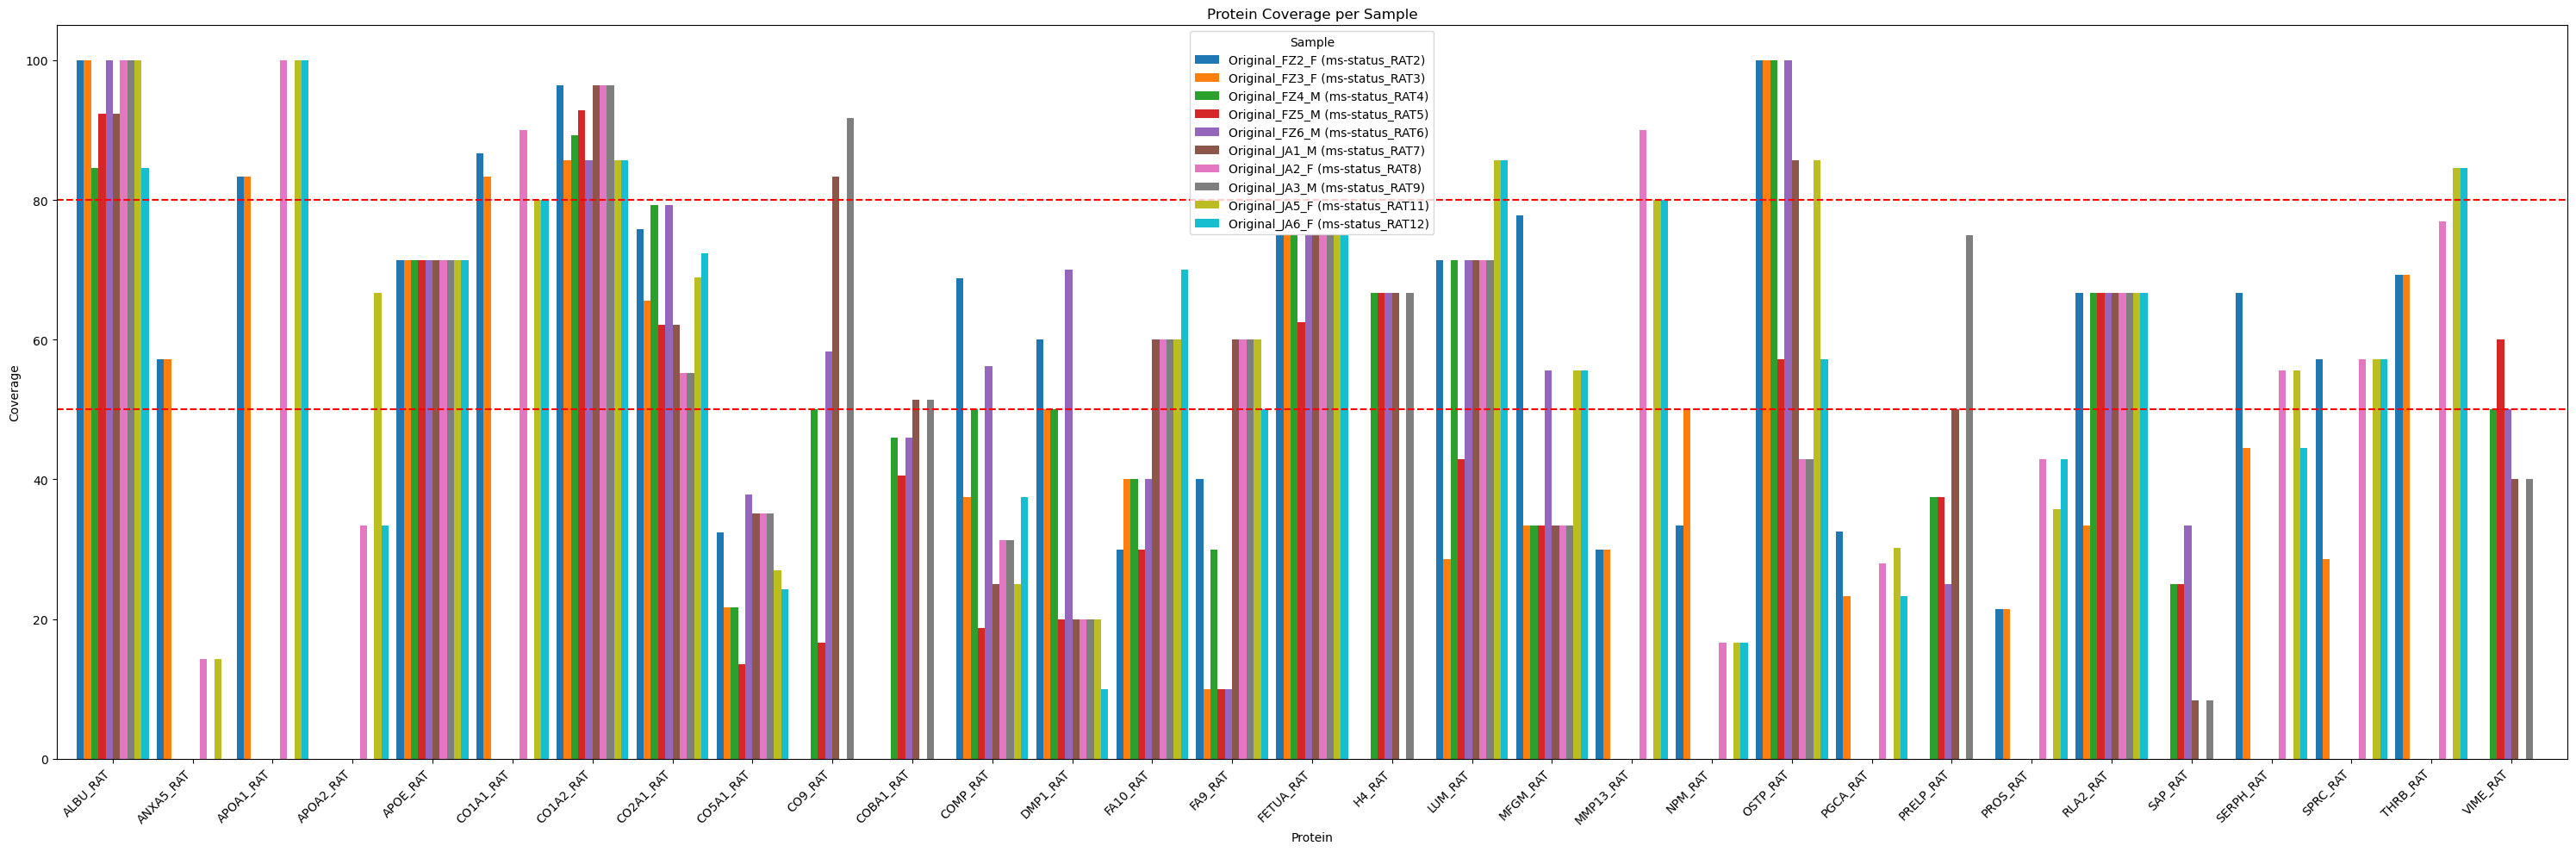

In [66]:
bothdat = pd.concat([fcov, mcov])
# Pivot so each protein is a group, samples are bars
pivot_df = bothdat.pivot(index='Protein', columns='Sample', values='Cov')


# Bigger figure + adjust bar width
ax = pivot_df.plot(kind='bar', figsize=(30,10), width=0.9)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Threshold = 50')
ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Threshold = 80')

plt.ylabel('Coverage')
plt.title('Protein Coverage per Sample')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("all_samples_protein_coverage.svg", format="svg", bbox_inches="tight")
plt.show()

In [11]:
# Find common proteins - takes in two lists
def findCommon(data):
    # Convert lists to sets
    set1 = set(data[0])
    set2 = set(data[1])
    print(set1, set2)

    # Find intersection
    common_strings = set1.intersection(set2)

    common_proteins = set1 & set2
    unique_to_list1 = set1 - set2
    unique_to_list2 = set2 - set1

    # Convert the result back to a list if needed
    common_strings_list = list(common_strings)
    proteins_in_both = common_strings_list
    results = {
        'unique_to_g1': unique_to_list1,
        'unique_to_g2': unique_to_list2,
        'common_to_both': proteins_in_both
    }
    return results
commonUnfiltered = findCommon([data_f['Uniprot_ID'], data_m['Uniprot_ID']])
commonUnfiltered = commonUnfiltered['common_to_both']
commonFiltered = findCommon([female_un_sig_proteins, male_un_sig_proteins])
commonFiltered = commonFiltered['common_to_both']

{'ROB1_RAT', 'CERU_RAT', 'TPM4_RAT', 'IGF1_RAT', 'CAB45_RAT', 'RIPR2_RAT', 'TRFE_RAT', 'RLA2_RAT', 'K1C10_RAT', 'NUCB2_RAT', 'SERPH_RAT', 'A4_RAT', 'MCPT8_RAT', 'SPRC_RAT', 'MK_RAT', 'LUM_RAT', 'PPA5_RAT', 'IGG2C_RAT', 'CALR_RAT', 'OLFL3_RAT', 'NUCB1_RAT', 'APOE_RAT', 'ENPL_RAT', 'HPT_RAT', 'GELS_RAT', 'CEAM1_RAT', 'ANXA1_RAT', 'K22E_RAT', 'PRG2_RAT', 'FA9_RAT', 'CBPQ_RAT', 'CLUS_RAT', 'FA7_RAT', 'CATB_RAT', 'CCD80_RAT', 'COMP_RAT', 'OSTP_RAT', 'HS90B_RAT', 'CO1A1_RAT', 'MFGM_RAT', 'FA10_RAT', 'GRZ2_RAT', 'APOA2_RAT', 'ADT2_RAT', 'PPBT_RAT', 'ALBU_RAT', 'CBPA3_RAT', 'CO5A1_RAT', 'TBA1B_RAT', 'MMP13_RAT', 'CBPZ_RAT', '1433T_RAT', 'CNMD_RAT', 'CO2A1_RAT', 'TFR1_RAT', 'SRPX2_RAT', 'K2C1_RAT', 'HEP2_RAT', 'CO3_RAT', 'FETUA_RAT', 'HSP7C_RAT', 'APOA1_RAT', 'PGS2_RAT', 'MMP2_RAT', 'CO1A2_RAT', 'AN32B_RAT', 'ATPA_RAT', 'IGG2B_RAT', 'CMGA_RAT', 'NID2_RAT', 'ILEUA_RAT', 'DMP1_RAT', 'RL24_RAT', 'FNDC1_RAT', 'K2C5_RAT', 'ANXA2_RAT', 'ANXA5_RAT', 'THRB_RAT', 'HTRA1_RAT', 'PGCA_RAT', 'EF2_RAT', 'FET

In [14]:
m = data_m[data_m['Uniprot_ID'].isin(male_un_sig_proteins)]
sig_prot_cov_m = identifyCoverage(m)
f = data_f[data_f['Uniprot_ID'].isin(female_un_sig_proteins)]
sig_prot_cov_f = identifyCoverage(f)

index_labels = ['Young_f', 'Old_f', 'Young_m', 'Old_m']
sig_prot_cov_both_f = sig_prot_cov_f[commonFiltered]
sig_prot_cov_both_m = sig_prot_cov_m[commonFiltered]
sig_prot_cov_both = pd.concat([sig_prot_cov_both_f, sig_prot_cov_both_m], axis=0)
sig_prot_cov_both.index = index_labels
sig_prot_cov_f

prot    Uniprot_ID                    Domain_Name  Domain_Start  Domain_Finish  \
25   OSTP_RAT         50Step_Domain_p0_to_50             0             50   
26   OSTP_RAT   50Step_Domain_p50.0_to_100.0            50            100   
27   OSTP_RAT  50Step_Domain_p100.0_to_150.0           100            150   
28   OSTP_RAT  50Step_Domain_p150.0_to_200.0           150            200   
29   OSTP_RAT  50Step_Domain_p200.0_to_250.0           200            250   
30   OSTP_RAT  50Step_Domain_p250.0_to_300.0           250            300   
31   OSTP_RAT  50Step_Domain_p300.0_to_317.0           300            317   

    p: Old vs Young   Domain Type  Domain_Length  FZ4_M (ms-status_RAT4)  \
25           0.0077  50.0 AA STEP             50                       1   
26           0.3836  50.0 AA STEP             50                       2   
27           1.0000  50.0 AA STEP             50                       3   
28           0.2247  50.0 AA STEP             50                      13  

prot     Uniprot_ID                      Domain_Name  Domain_Start  Domain_Finish  \
337  CO5A1_RAT           50Step_Domain_p0_to_50             0             50   
338  CO5A1_RAT     50Step_Domain_p50.0_to_100.0            50            100   
339  CO5A1_RAT    50Step_Domain_p100.0_to_150.0           100            150   
340  CO5A1_RAT    50Step_Domain_p150.0_to_200.0           150            200   
341  CO5A1_RAT    50Step_Domain_p200.0_to_250.0           200            250   
342  CO5A1_RAT    50Step_Domain_p250.0_to_300.0           250            300   
343  CO5A1_RAT    50Step_Domain_p300.0_to_350.0           300            350   
344  CO5A1_RAT    50Step_Domain_p350.0_to_400.0           350            400   
345  CO5A1_RAT    50Step_Domain_p400.0_to_450.0           400            450   
346  CO5A1_RAT    50Step_Domain_p450.0_to_500.0           450            500   
347  CO5A1_RAT    50Step_Domain_p500.0_to_550.0           500            550   
348  CO5A1_RAT    50Step_Domain_p55

prot     Uniprot_ID                    Domain_Name  Domain_Start  Domain_Finish  \
386  ANXA5_RAT         50Step_Domain_p0_to_50             0             50   
387  ANXA5_RAT   50Step_Domain_p50.0_to_100.0            50            100   
388  ANXA5_RAT  50Step_Domain_p100.0_to_150.0           100            150   
389  ANXA5_RAT  50Step_Domain_p150.0_to_200.0           150            200   
390  ANXA5_RAT  50Step_Domain_p200.0_to_250.0           200            250   
391  ANXA5_RAT  50Step_Domain_p250.0_to_300.0           250            300   
392  ANXA5_RAT  50Step_Domain_p300.0_to_319.0           300            319   

     p: Aged vs Young   Domain Type  Domain_Length  FZ1_F (ms-status_RAT1)  \
386            0.1533  50.0 AA STEP             50                       1   
387            1.0000  50.0 AA STEP             50                       1   
388            0.0364  50.0 AA STEP             50                       1   
389            0.5551  50.0 AA STEP             50        

prot      Uniprot_ID                      Domain_Name  Domain_Start  Domain_Finish  \
1113   PGCA_RAT           50Step_Domain_p0_to_50             0             50   
1114   PGCA_RAT     50Step_Domain_p50.0_to_100.0            50            100   
1115   PGCA_RAT    50Step_Domain_p100.0_to_150.0           100            150   
1116   PGCA_RAT    50Step_Domain_p150.0_to_200.0           150            200   
1117   PGCA_RAT    50Step_Domain_p200.0_to_250.0           200            250   
1118   PGCA_RAT    50Step_Domain_p250.0_to_300.0           250            300   
1119   PGCA_RAT    50Step_Domain_p300.0_to_350.0           300            350   
1120   PGCA_RAT    50Step_Domain_p350.0_to_400.0           350            400   
1121   PGCA_RAT    50Step_Domain_p400.0_to_450.0           400            450   
1122   PGCA_RAT    50Step_Domain_p450.0_to_500.0           450            500   
1123   PGCA_RAT    50Step_Domain_p500.0_to_550.0           500            550   
1124   PGCA_RAT    50St

NameError: name 'commonFiltered' is not defined

In [15]:
f.head()

,Uniprot_ID,Domain_Name,Domain_Start,Domain_Finish,p: Aged vs Young,Domain Type,Domain_Length,FZ1_F (ms-status_RAT1),FZ2_F (ms-status_RAT2),FZ3_F (ms-status_RAT3),JA2_F (ms-status_RAT8),JA5_F (ms-status_RAT11),JA6_F (ms-status_RAT12),Diff Young vs old (average young - old / 50),Average Young,Average Old,Peptides contributing to Young,Peptides contributing to Old,Original_FZ1_F (ms-status_RAT1),Original_FZ2_F (ms-status_RAT2),Original_FZ3_F (ms-status_RAT3),Original_JA2_F (ms-status_RAT8),Original_JA5_F (ms-status_RAT11),Original_JA6_F (ms-status_RAT12),GeneAC,Uniprot_ACs,Uniprot_Domain
45,LUM_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.00,0,0,NaN,NaN,0,0,0,0,0,0,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p0_to_50
46,LUM_RAT,50Step_Domain_p50.0_to_100.0,50,100,1.0000,50.0 AA STEP,50,0,1,0,0,1,1,-0.02,0,1,NaN,YLYLRNNQIDHIDEK,0,1,0,0,2,1,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p50.0_to_100.0
47,LUM_RAT,50Step_Domain_p100.0_to_150.0,100,150,0.0343,50.0 AA STEP,50,2,0,0,4,3,3,-0.04,1,3,NaN,SLQDLQLANNK SLQDLQLANNKISK,1,0,0,5,6,3,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p100.0_to_150.0
48,LUM_RAT,50Step_Domain_p150.0_to_200.0,150,200,0.9646,50.0 AA STEP,50,0,1,4,4,3,2,-0.02,2,3,SLEYLDLSFNQMSK,SLEYLDLSFNQMSK SLQDLQLANNKISK,0,1,1,5,6,2,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p150.0_to_200.0
49,LUM_RAT,50Step_Domain_p200.0_to_250.0,200,250,1.0000,50.0 AA STEP,50,2,3,0,2,2,3,0.00,2,2,NaN,FTGLQYLR ITNIPDEYFNR,1,2,0,2,4,3,LUM_RAT,P51886;\r,LUM_RAT_50Step_Domain_p200.0_to_250.0


In [13]:
categories = sig_prot_cov_both
values = []
#for p in sig_prot_cov_both:
 #   data = list(sig_prot_cov_both[p])
  #  values.append(data)
for r in sig_prot_cov_both.iterrows():
    data = list(r)
    values.append(data)
values[3][0]

'Old_m'

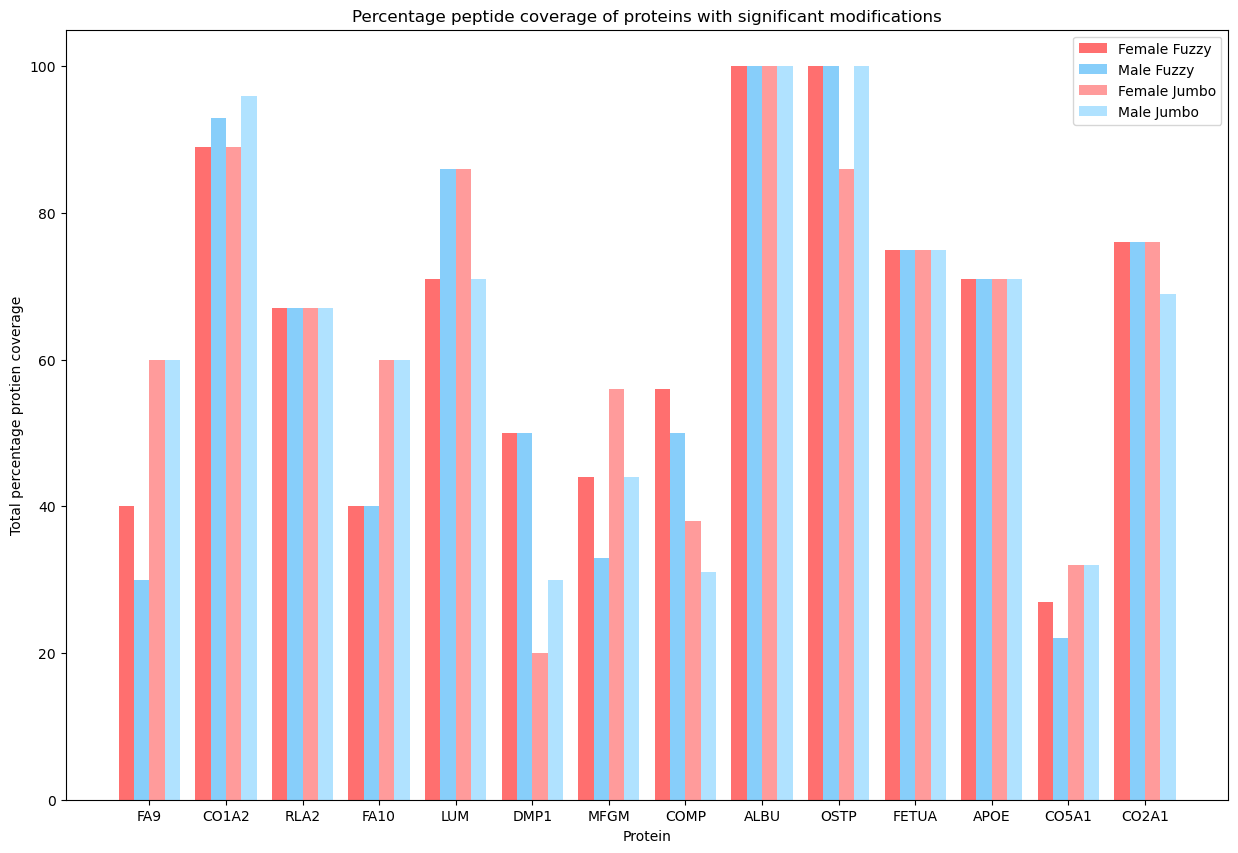

In [16]:
categories = list(sig_prot_cov_both)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_both.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.2

colors = ['#FF6F6F', '#FF9B9B', '#87CEFA', '#B0E2FF']

fig = plt.figure(figsize=(15, 10))
# Create the bar plot
plt.bar(x - width*1.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
plt.bar(x - width*0.5, values[2][1], width, label='Male Fuzzy', color=colors[2])
plt.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])
plt.bar(x + width*1.5, values[3][1], width, label='Male Jumbo', color=colors[3])

# Add horizontal lines
# plt.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# plt.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')

# Add region labels
# plt.text(x=13.75, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# plt.text(x=13.75, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# plt.text(x=13.5, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')

# Add title and labels
plt.title('Percentage peptide coverage of proteins with significant modifications')
plt.xlabel('Protein')
plt.ylabel('Total percentage protien coverage')
plt.xticks(x, categories)

# Add legend
plt.legend()

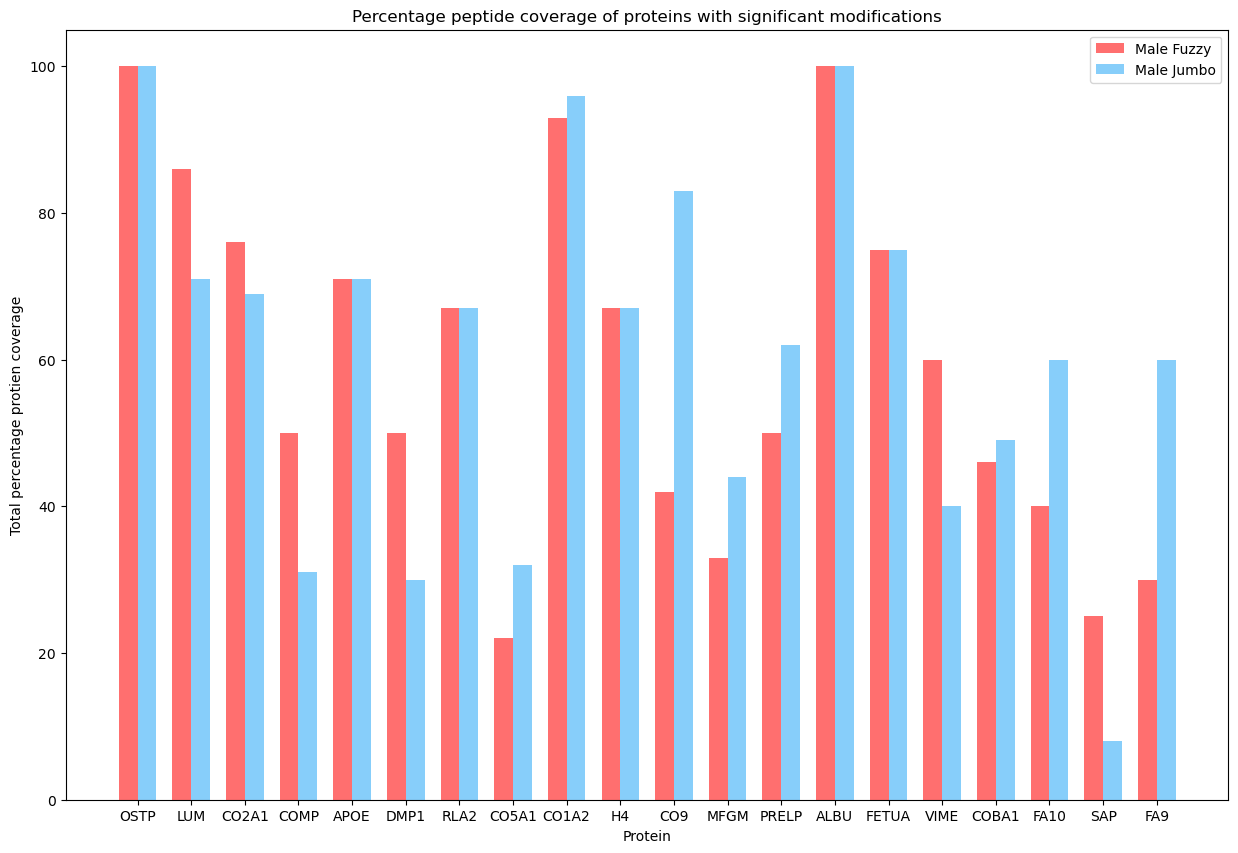

In [17]:
categories = list(sig_prot_cov_m)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_m.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

fig = plt.figure(figsize=(15, 10))
# Create the bar plot
plt.bar(x - width*0.5, values[0][1], width, label='Male Fuzzy', color=colors[0])
plt.bar(x + width*0.5, values[1][1], width, label='Male Jumbo', color=colors[1])

# Add horizontal lines
# plt.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# plt.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')

# Add region labels
# plt.text(x=19.5, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# plt.text(x=19.5, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# plt.text(x=19.2, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')

# Add title and labels
plt.title('Percentage peptide coverage of proteins with significant modifications')
plt.xlabel('Protein')
plt.ylabel('Total percentage protien coverage')
plt.xticks(x, categories)

# Add legend
plt.legend()

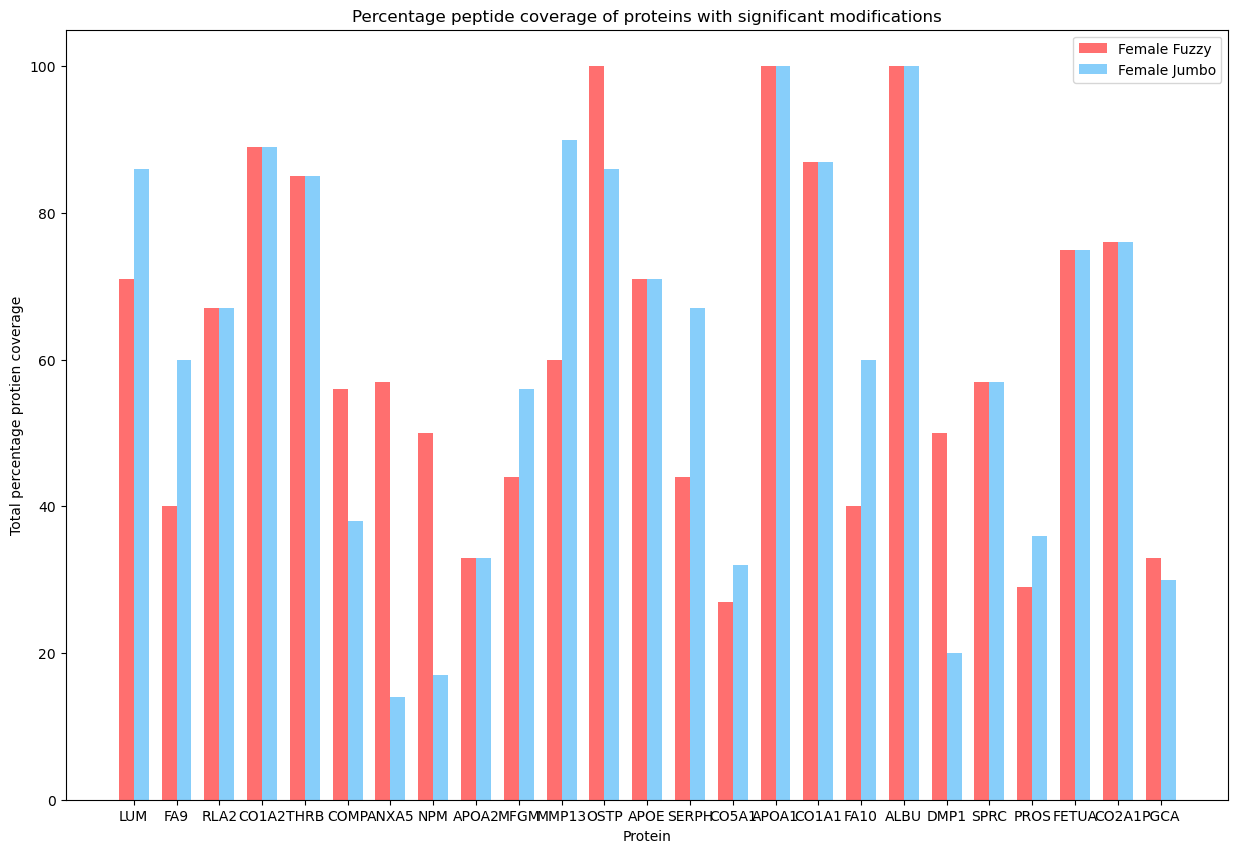

In [18]:
categories = list(sig_prot_cov_f)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_f.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

fig = plt.figure(figsize=(15, 10))
# Create the bar plot
plt.bar(x - width*0.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
plt.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])

# Add horizontal lines
# plt.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# plt.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')

# Add region labels
# plt.text(x=24.3, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# plt.text(x=24.3, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# plt.text(x=24.3, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')

# Add title and labels
plt.title('Percentage peptide coverage of proteins with significant modifications')
plt.xlabel('Protein')
plt.ylabel('Total percentage protien coverage')
plt.xticks(x, categories)

# Add legend
plt.legend()

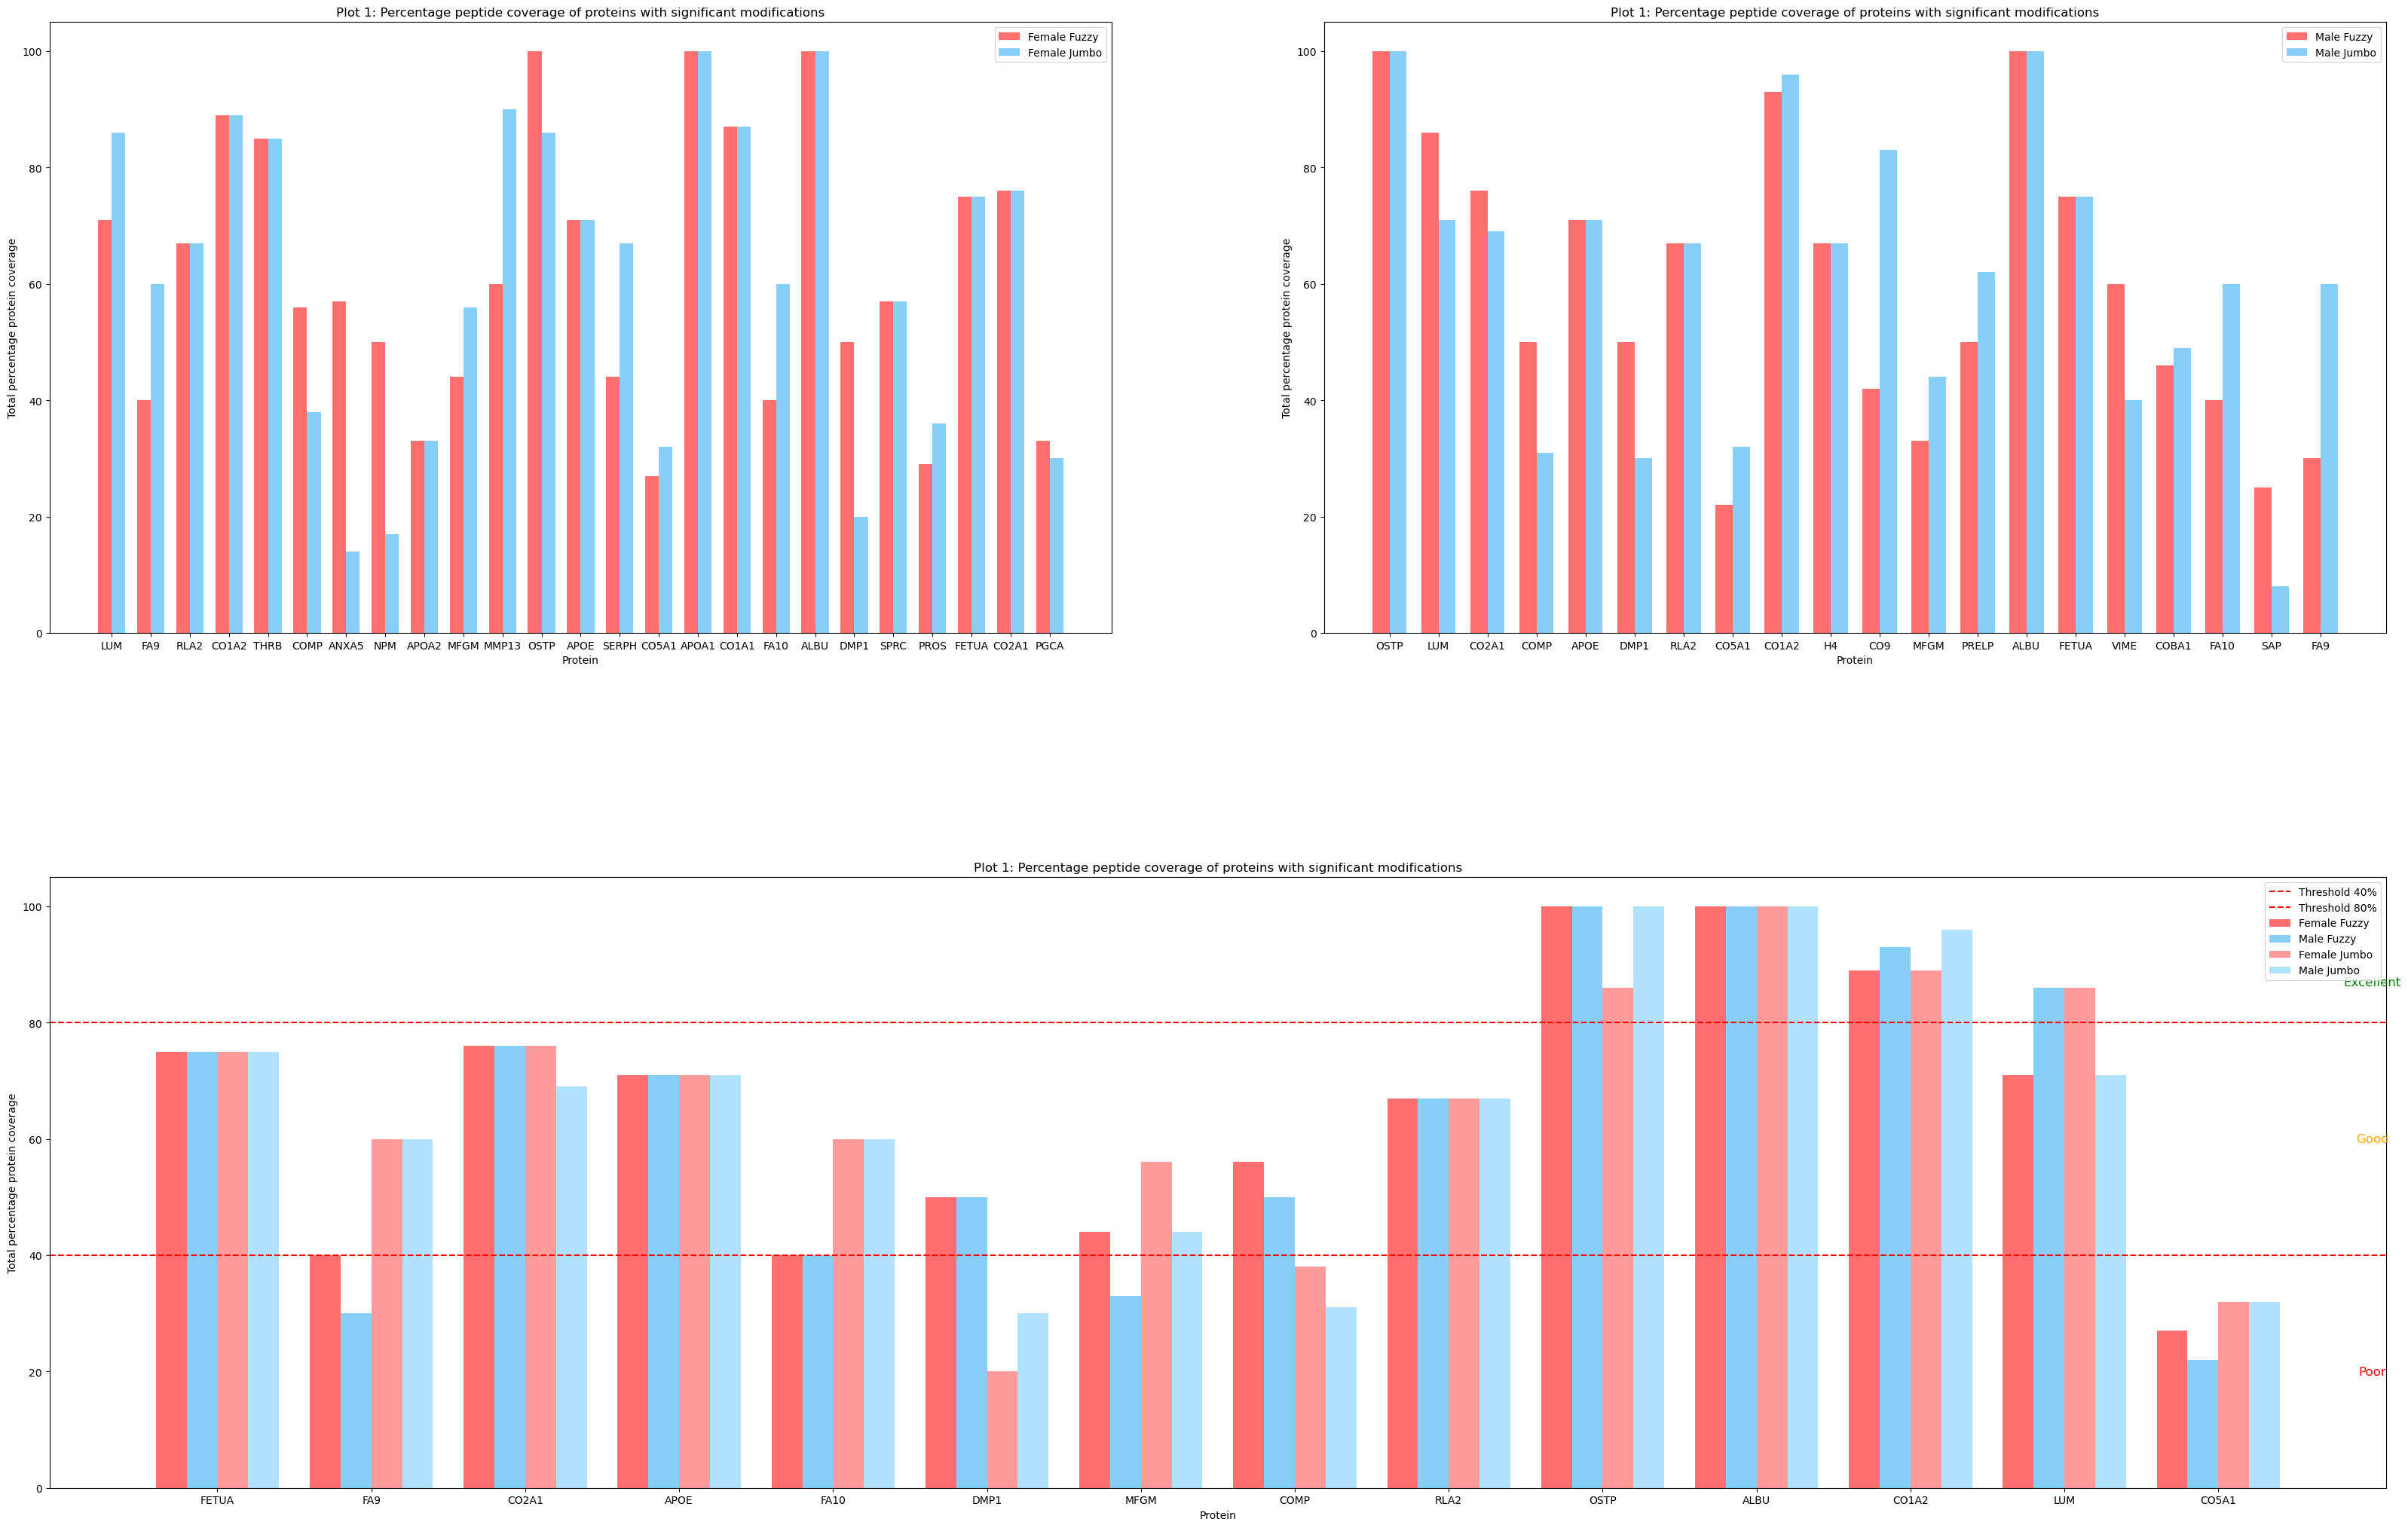

In [20]:
# Define figure and GridSpec layout
fig = plt.figure(figsize=(40, 40))
gs = GridSpec(3, 2, height_ratios=[2, 2, 2], width_ratios=[1 ,1], hspace=0.4)

categories = list(sig_prot_cov_f)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_f.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

axs1 = plt.subplot(gs[0,0])
axs1.bar(x - width*0.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
axs1.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])
# axs1.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs1.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs1.text(x=24.3, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs1.text(x=24.3, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs1.text(x=24.3, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs1.set_title('Plot 1: Percentage peptide coverage of proteins with significant modifications')
axs1.set_xlabel('Protein')
axs1.set_ylabel('Total percentage protein coverage')
axs1.set_xticks(x)
axs1.set_xticklabels(categories)
axs1.legend()


categories = list(sig_prot_cov_m)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_m.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

axs2 = plt.subplot(gs[0,1])
axs2.bar(x - width*0.5, values[0][1], width, label='Male Fuzzy', color=colors[0])
axs2.bar(x + width*0.5, values[1][1], width, label='Male Jumbo', color=colors[1])
# axs2.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs2.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs2.text(x=20.3, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs2.text(x=20.3, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs2.text(x=20.3, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs2.set_title('Plot 1: Percentage peptide coverage of proteins with significant modifications')
axs2.set_xlabel('Protein')
axs2.set_ylabel('Total percentage protein coverage')
axs2.set_xticks(x)
axs2.set_xticklabels(categories)
axs2.legend()

categories = list(sig_prot_cov_both)
cleaned = []
for p in categories:
    cleaned.append(p.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_both.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)

# Width of each bar
width = 0.2

colors = ['#FF6F6F', '#FF9B9B', '#87CEFA', '#B0E2FF']

axs3 = plt.subplot(gs[1,:])
axs3.bar(x - width*1.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
axs3.bar(x - width*0.5, values[2][1], width, label='Male Fuzzy', color=colors[2])
axs3.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])
axs3.bar(x + width*1.5, values[3][1], width, label='Male Jumbo', color=colors[3])
# axs3.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs3.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs3.text(x=14, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs3.text(x=14, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs3.text(x=14, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs3.set_title('Plot 1: Percentage peptide coverage of proteins with significant modifications')
axs3.set_xlabel('Protein')
axs3.set_ylabel('Total percentage protein coverage')
axs3.set_xticks(x)
axs3.set_xticklabels(categories)
axs3.legend()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


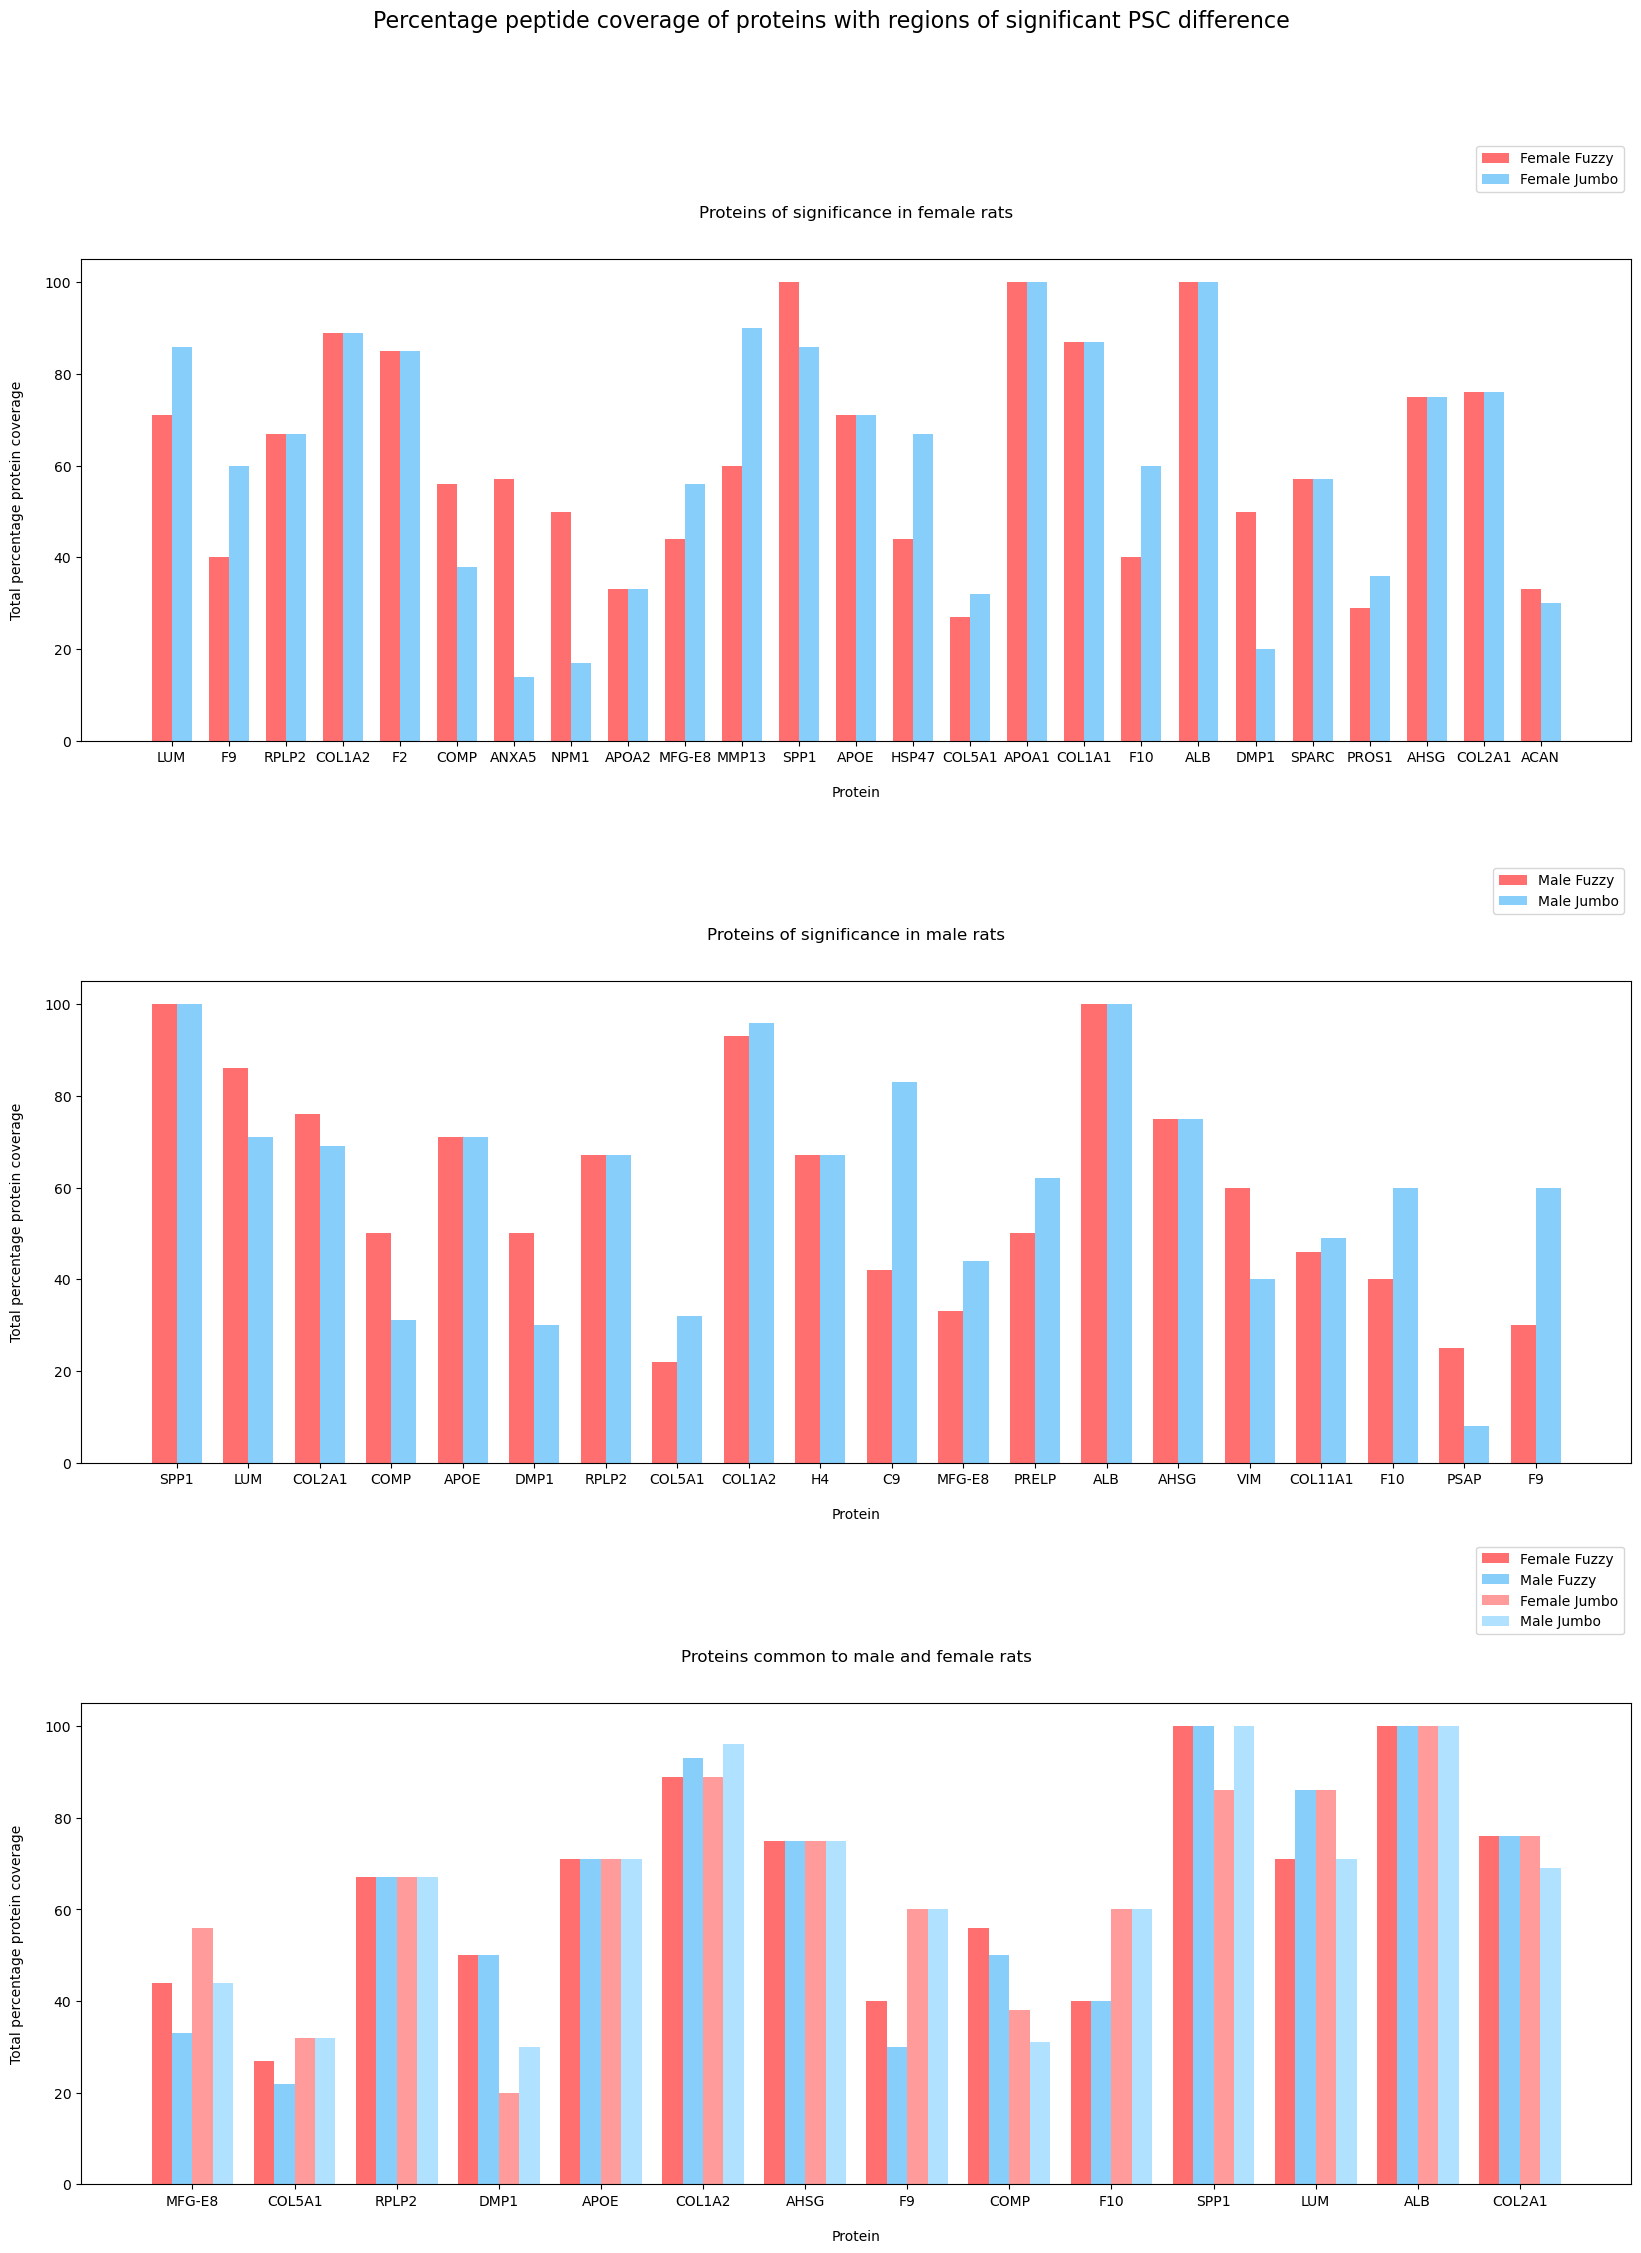

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(20, 25))
fig.suptitle('Percentage peptide coverage of proteins with regions of significant PSC difference', fontsize=16)
categories = list(sig_prot_cov_f)
cleaned = []
for newstring in categories:
    if 'CO9' in newstring:
        newstring = newstring.replace('CO9', 'C9')
    if 'CO1' in newstring:
        newstring = newstring.replace('CO1', 'COL1')
    if 'CO2' in newstring:
        newstring = newstring.replace('CO2', 'COL2')
    if 'COB' in newstring:
        newstring = newstring.replace('COB', 'COL11')
    if 'CO5' in newstring:
        newstring = newstring.replace('CO5', 'COL5')
    if 'ALBU' in newstring:
        newstring = newstring.replace('ALBU', 'ALB')
    if 'A6JEK6' in newstring:
        newstring = newstring.replace('A6JEK6', 'CHGA')
    if 'Matrilin-1' in newstring:
        newstring = newstring.replace('Matrilin-1', 'MTN1')
    if 'OSTP' in newstring:
        newstring = newstring.replace('OSTP', 'SPP1')
    if 'FA9' in newstring:
        newstring = newstring.replace('FA9', 'F9')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'PGCA' in newstring:
        newstring = newstring.replace('PGCA', 'ACAN')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'SPRC' in newstring:
        newstring = newstring.replace('SPRC', 'SPARC')
    if 'SERPH' in newstring:
        newstring = newstring.replace('SERPH', 'HSP47')
    if 'RLA2' in newstring:
        newstring = newstring.replace('RLA2', 'RPLP2')
    if 'NPM' in newstring:
        newstring = newstring.replace('NPM', 'NPM1')
    if 'SAP' in newstring:
        newstring = newstring.replace('SAP', 'PSAP')
    if 'MFGM' in newstring:
        newstring = newstring.replace('MFGM', 'MFG-E8')
    if 'PROS' in newstring:
        newstring = newstring.replace('PROS', 'PROS1')
    if 'THRB' in newstring:
        newstring = newstring.replace('THRB', 'F2')
    if 'FETUA' in newstring:
        newstring = newstring.replace('FETUA', 'AHSG')
    if 'VIME' in newstring:
        newstring = newstring.replace('VIME', 'VIM')
    cleaned.append(newstring.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_f.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)
print(x)
# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

axs1 = axs[0]
axs1.bar(x - width*0.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
axs1.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])
# axs1.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs1.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs1.text(x=24.3, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs1.text(x=24.3, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs1.text(x=24.3, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs1.set_title('Proteins of significance in female rats', pad=30)
axs1.set_xlabel('Protein', labelpad=15)
axs1.set_ylabel('Total percentage protein coverage', labelpad=15)
axs1.set_xticks(x)
axs1.set_xticklabels(categories)
axs1.legend(loc='upper right', bbox_to_anchor=(1, 1.25))
# axs1.text(-1.5, 120, 'D', fontsize=16, fontweight='bold')


categories = list(sig_prot_cov_m)
cleaned = []
for newstring in categories:
    if 'CO9' in newstring:
        newstring = newstring.replace('CO9', 'C9')
    if 'CO1' in newstring:
        newstring = newstring.replace('CO1', 'COL1')
    if 'CO2' in newstring:
        newstring = newstring.replace('CO2', 'COL2')
    if 'COB' in newstring:
        newstring = newstring.replace('COB', 'COL11')
    if 'CO5' in newstring:
        newstring = newstring.replace('CO5', 'COL5')
    if 'ALBU' in newstring:
        newstring = newstring.replace('ALBU', 'ALB')
    if 'A6JEK6' in newstring:
        newstring = newstring.replace('A6JEK6', 'CHGA')
    if 'Matrilin-1' in newstring:
        newstring = newstring.replace('Matrilin-1', 'MTN1')
    if 'OSTP' in newstring:
        newstring = newstring.replace('OSTP', 'SPP1')
    if 'FA9' in newstring:
        newstring = newstring.replace('FA9', 'F9')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'PGCA' in newstring:
        newstring = newstring.replace('PGCA', 'ACAN')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'SPRC' in newstring:
        newstring = newstring.replace('SPRC', 'SPARC')
    if 'SERPH' in newstring:
        newstring = newstring.replace('SERPH', 'HSP47')
    if 'RLA2' in newstring:
        newstring = newstring.replace('RLA2', 'RPLP2')
    if 'NPM' in newstring:
        newstring = newstring.replace('NPM', 'NPM1')
    if 'SAP' in newstring:
        newstring = newstring.replace('SAP', 'PSAP')
    if 'MFGM' in newstring:
        newstring = newstring.replace('MFGM', 'MFG-E8')
    if 'PROS' in newstring:
        newstring = newstring.replace('PROS', 'PROS1')
    if 'THRB' in newstring:
        newstring = newstring.replace('THRB', 'F2')
    if 'FETUA' in newstring:
        newstring = newstring.replace('FETUA', 'AHSG')
    if 'VIME' in newstring:
        newstring = newstring.replace('VIME', 'VIM')
    cleaned.append(newstring.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_m.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)
print(x)
# Width of each bar
width = 0.35

colors = ['#FF6F6F', '#87CEFA']

axs2 = axs[1]
axs2.bar(x - width*0.5, values[0][1], width, label='Male Fuzzy', color=colors[0])
axs2.bar(x + width*0.5, values[1][1], width, label='Male Jumbo', color=colors[1])
# axs2.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs2.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs2.text(x=20.3, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs2.text(x=20.3, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs2.text(x=20.3, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs2.set_title('Proteins of significance in male rats', pad=30)
axs2.set_xlabel('Protein', labelpad=15)
axs2.set_ylabel('Total percentage protein coverage', labelpad=15)
axs2.set_xticks(x)
axs2.set_xticklabels(categories)
axs2.legend(loc='upper right', bbox_to_anchor=(1, 1.25))
# axs2.text(-1.5, 120, 'E', fontsize=16, fontweight='bold')

categories = list(sig_prot_cov_both)
cleaned = []
for newstring in categories:
    if 'CO9' in newstring:
        newstring = newstring.replace('CO9', 'C9')
    if 'CO1' in newstring:
        newstring = newstring.replace('CO1', 'COL1')
    if 'CO2' in newstring:
        newstring = newstring.replace('CO2', 'COL2')
    if 'COB' in newstring:
        newstring = newstring.replace('COB', 'COL11')
    if 'CO5' in newstring:
        newstring = newstring.replace('CO5', 'COL5')
    if 'ALBU' in newstring:
        newstring = newstring.replace('ALBU', 'ALB')
    if 'A6JEK6' in newstring:
        newstring = newstring.replace('A6JEK6', 'CHGA')
    if 'Matrilin-1' in newstring:
        newstring = newstring.replace('Matrilin-1', 'MTN1')
    if 'OSTP' in newstring:
        newstring = newstring.replace('OSTP', 'SPP1')
    if 'FA9' in newstring:
        newstring = newstring.replace('FA9', 'F9')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'PGCA' in newstring:
        newstring = newstring.replace('PGCA', 'ACAN')
    if 'FA10' in newstring:
        newstring = newstring.replace('FA10', 'F10')
    if 'SPRC' in newstring:
        newstring = newstring.replace('SPRC', 'SPARC')
    if 'SERPH' in newstring:
        newstring = newstring.replace('SERPH', 'HSP47')
    if 'RLA2' in newstring:
        newstring = newstring.replace('RLA2', 'RPLP2')
    if 'NPM' in newstring:
        newstring = newstring.replace('NPM', 'NPM1')
    if 'SAP' in newstring:
        newstring = newstring.replace('SAP', 'PSAP')
    if 'MFGM' in newstring:
        newstring = newstring.replace('MFGM', 'MFG-E8')
    if 'PROS' in newstring:
        newstring = newstring.replace('PROS', 'PROS1')
    if 'THRB' in newstring:
        newstring = newstring.replace('THRB', 'F2')
    if 'FETUA' in newstring:
        newstring = newstring.replace('FETUA', 'AHSG')
    if 'VIME' in newstring:
        newstring = newstring.replace('VIME', 'VIM')
    cleaned.append(newstring.replace('_RAT', ''))
categories = cleaned
values = []
for r in sig_prot_cov_both.iterrows():
    data = list(r)
    values.append(data)

# Number of categories
n_categories = len(categories)

# Position of bars on x-axis
x = np.arange(n_categories)
print(x)
# Width of each bar
width = 0.2

colors = ['#FF6F6F', '#FF9B9B', '#87CEFA', '#B0E2FF']

axs3 = axs[2]
axs3.bar(x - width*1.5, values[0][1], width, label='Female Fuzzy', color=colors[0])
axs3.bar(x - width*0.5, values[2][1], width, label='Male Fuzzy', color=colors[2])
axs3.bar(x + width*0.5, values[1][1], width, label='Female Jumbo', color=colors[1])
axs3.bar(x + width*1.5, values[3][1], width, label='Male Jumbo', color=colors[3])
# axs3.axhline(y=40, color='r', linestyle='--', label='Threshold 40%')
# axs3.axhline(y=80, color='r', linestyle='--', label='Threshold 80%')
# axs3.text(x=14, y=20, s='Poor', va='center', ha='center', fontsize=12, color='red')
# axs3.text(x=14, y=60, s='Good', va='center', ha='center', fontsize=12, color='orange')
# axs3.text(x=14, y=87, s='Excellent', va='center', ha='center', fontsize=12, color='green')
axs3.set_title('Proteins common to male and female rats', pad=30)
axs3.set_xlabel('Protein', labelpad=15)
axs3.set_ylabel('Total percentage protein coverage', labelpad=15)
axs3.set_xticks(x)
axs3.set_xticklabels(categories)
axs3.legend(loc='upper right', bbox_to_anchor=(1, 1.34))
# axs3.text(-1.5, 120, 'F', fontsize=16, fontweight='bold')

plt.subplots_adjust(hspace=0.5)  # Adjust the vertical space between subplots
plt.savefig('percentage_coverage.svg', format='svg')
plt.show()

In [15]:
proteins = findCommon([female_un_sig_proteins, male_un_sig_proteins])
proteins['unique_to_g2']

print(f"Female: {proteins['unique_to_g1']}, {len(proteins['unique_to_g1'])}")
print(f"Male: {proteins['unique_to_g2']}, {len(proteins['unique_to_g2'])}")
print(f"Common: {proteins['common_to_both']}, {len(proteins['common_to_both'])}")

{'APOE_RAT', 'SERPH_RAT', 'RLA2_RAT', 'CO5A1_RAT', 'CO1A2_RAT', 'DMP1_RAT', 'FA10_RAT', 'PGCA_RAT', 'FA9_RAT', 'COMP_RAT', 'ANXA5_RAT', 'APOA1_RAT', 'PROS_RAT', 'CO2A1_RAT', 'ALBU_RAT', 'LUM_RAT', 'MMP13_RAT', 'CO1A1_RAT', 'SPRC_RAT', 'FETUA_RAT', 'NPM_RAT', 'OSTP_RAT', 'APOA2_RAT', 'MFGM_RAT', 'THRB_RAT'} {'APOE_RAT', 'RLA2_RAT', 'CO5A1_RAT', 'CO1A2_RAT', 'DMP1_RAT', 'FA10_RAT', 'FA9_RAT', 'COMP_RAT', 'VIME_RAT', 'H4_RAT', 'COBA1_RAT', 'CO2A1_RAT', 'ALBU_RAT', 'LUM_RAT', 'SAP_RAT', 'FETUA_RAT', 'CO9_RAT', 'PRELP_RAT', 'OSTP_RAT', 'MFGM_RAT'}
Female: {'MMP13_RAT', 'ANXA5_RAT', 'APOA1_RAT', 'CO1A1_RAT', 'NPM_RAT', 'SERPH_RAT', 'APOA2_RAT', 'SPRC_RAT', 'PROS_RAT', 'PGCA_RAT', 'THRB_RAT'}, 11
Male: {'CO9_RAT', 'PRELP_RAT', 'VIME_RAT', 'H4_RAT', 'COBA1_RAT', 'SAP_RAT'}, 6
Common: ['APOE_RAT', 'FA9_RAT', 'ALBU_RAT', 'LUM_RAT', 'COMP_RAT', 'CO5A1_RAT', 'RLA2_RAT', 'OSTP_RAT', 'MFGM_RAT', 'CO1A2_RAT', 'DMP1_RAT', 'CO2A1_RAT', 'FA10_RAT', 'FETUA_RAT'], 14


In [40]:
len(proteins['unique_to_g1'])

11

In [ ]:
# 'Proteins with statistically significant regional differences in average peptide spectral count'
plt.figure(figsize=(4,4))
plt.title('Proteins with statistically significant regional differences in average PSC', pad=50)
# Add annotations for the unique proteins

# split list into 5 word comma seperated lists
newProtObj = {
    'unique_to_g1': [],
    'unique_to_g2': [],
    'common_to_both': []
}
for key, value in proteins.items():
    v = list(value)
    newlist = []
    if key == 'unique_to_g1':
        for i in range(math.ceil(len(v)/2)):
            newstring = ', '.join(v[i*2:(i+1)*2])  # Slicing the list in chunks of 5 elements
            newlist.append(newstring)
        newProtObj[key] = newlist
    elif key == 'unique_to_g2':
        for i in range(math.ceil(len(v)/3)):
            newstring = ', '.join(v[i*3:(i+1)*3])  # Slicing the list in chunks of 5 elements
            newlist.append(newstring)
        newProtObj[key] = newlist
    else:
        for i in range(math.ceil(len(v)/5)):
            newstring = ', '.join(v[i*5:(i+1)*5])  # Slicing the list in chunks of 5 elements
            newlist.append(newstring)
        newProtObj[key] = newlist

plt.text(1.4, 0.15, 'Female:\n'+'\n'.join(newProtObj['unique_to_g1']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='green', boxstyle='round,pad=0.5'))
plt.text(-1.2, 0.5, 'Male:\n'+'\n'.join(newProtObj['unique_to_g2']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='red', boxstyle='round,pad=0.5'))

# Add the common proteins below the diagram
plt.text(0, -1.1, 'Common Proteins:\n' + '\n'.join(newProtObj['common_to_both']), horizontalalignment='center', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='yellow', boxstyle='round,pad=0.5'))

venn2([set(male_un_sig_proteins), set(female_un_sig_proteins)], ('M', 'F'),  set_colors=('red', 'lightgreen', 'yellow'))
plt.show()
# plt.savefig('venn_significant_proteins.svg', format='svg')

In [ ]:
proteins

In [ ]:
import math

list1 = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']
list2 = []

# The correct range should start from 0 and go up to math.ceil(len(list1)/5)
for i in range(math.ceil(len(list1)/5)):
    newstring = ', '.join(list1[i*5:(i+1)*5])  # Slicing the list in chunks of 5 elements
    print(newstring)
    list1 = []
    list1 = .append(newstring)

list1

{'THRB_RAT', 'PGS1_RAT', 'FETUA_RAT', 'Matrilin-1', 'APOA1_RAT', 'A6JEK6_RAT', 'VIME_RAT', 'OSTP_RAT', 'ALBU_RAT'} {'MFGM_RAT', 'RLA2_RAT', 'PGCA_RAT', 'APOE_RAT', 'CO9_RAT', 'FETUA_RAT', 'APOA1_RAT', 'NPM_RAT', 'OSTP_RAT', 'ALBU_RAT', 'DMP1_RAT', 'CO1A2_RAT', 'FA9_RAT', 'ANXA5_RAT', 'CO1A1_RAT', 'MMP13_RAT', 'LUM_RAT', 'SPRC_RAT', 'THRB_RAT', 'PROS_RAT', 'COBA1_RAT', 'FA10_RAT', 'VIME_RAT', 'H4_RAT', 'CO2A1_RAT', 'SERPH_RAT', 'CO5A1_RAT', 'PRELP_RAT', 'SAP_RAT', 'COMP_RAT', 'APOA2_RAT'}
{'abundance': ['PGS1', 'CHGA', 'MTN1'], 'plf': ['MFGE8, RPLP2, ACAN, APOE, C9', 'NPM1, DMP1, COL1A2, F9, ANXA5', 'COL1A1, MMP13, LUM, SPARC, PROS1', 'COL11A1, F10, H4, COL2A1, HSP47', 'COL5A1, PRELP, PSAP, COMP, APOA2'], 'common_to_both': ['F2, AHSG, APOA1, VIM, SPP1, ALB']}


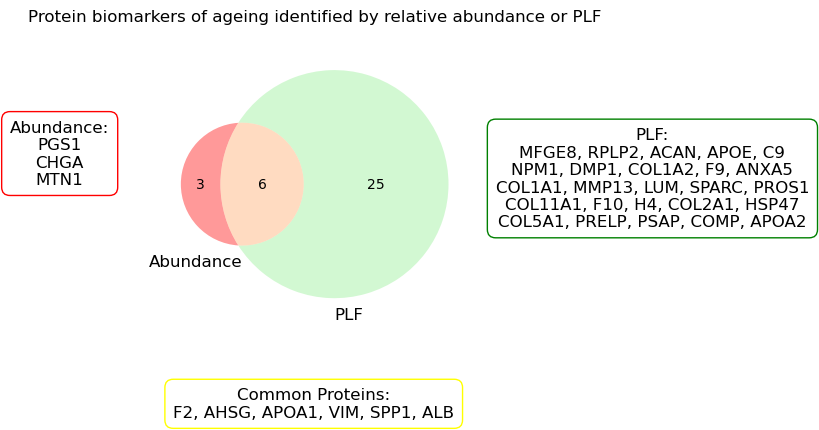

In [25]:
# Proteins identified as biomarkers based on abundance compared with those found using PLF
# Proteins Identified as biomarkers based on abundance:
# Abundance = {"Fetuin", "Chromogranin A", "Albumin", "Biglycan", "Apolipoprotein A-1", "Prothrombin", "Vimentin", "Osteopontin", "Matrilin-1"}
Abundance = {"FETUA_RAT", "A6JEK6_RAT", "ALBU_RAT", "PGS1_RAT", "APOA1_RAT", "THRB_RAT", "VIME_RAT", "OSTP_RAT", "Matrilin-1"}

# PLF identified proteins: 
PLF_ident = np.concatenate((male_un_sig_proteins, female_un_sig_proteins))
# Convert lists to sets
set1 = set(Abundance)
set2 = set(PLF_ident)
print(set1, set2)

# Find intersection
common_strings = set1.intersection(set2)

common_proteins = set1 & set2
unique_to_list1 = set1 - set2
unique_to_list2 = set2 - set1

# Convert the result back to a list if needed
common_strings_list = list(common_strings)
proteins_in_both = common_strings_list

abundance_plf_proteins = {
    'unique_to_List1': unique_to_list1,
    'unique_to_List2': unique_to_list2,
    'common_to_both': common_proteins,
}

# Plot venn
plt.figure(figsize=(4,4))
plt.title('Protein biomarkers of ageing identified by relative abundance or PLF', pad=20)

# split list into 5 word comma seperated lists
newProtObj = {
    'abundance': [],
    'plf': [],
    'common_to_both': []
}
for key, value in abundance_plf_proteins.items():
    v = list(value)
    newlist = []
    if key == 'unique_to_List1':
        for i in range(math.ceil(len(v)/1)):
            newstring = ', '.join(v[i*1:(i+1)*1])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            if 'CO9' in newstring:
                newstring = newstring.replace('CO9', 'C9')
            if 'CO1' in newstring:
                newstring = newstring.replace('CO1', 'COL1')
            if 'CO2' in newstring:
                newstring = newstring.replace('CO2', 'COL2')
            if 'COB' in newstring:
                newstring = newstring.replace('COB', 'COL11')
            if 'CO5' in newstring:
                newstring = newstring.replace('CO5', 'COL5')
            if 'ALBU' in newstring:
                newstring = newstring.replace('ALBU', 'ALB')
            if 'A6JEK6' in newstring:
                newstring = newstring.replace('A6JEK6', 'CHGA')
            if 'Matrilin-1' in newstring:
                newstring = newstring.replace('Matrilin-1', 'MTN1')
            if 'OSTP' in newstring:
                newstring = newstring.replace('OSTP', 'SPP1')
            if 'FA9' in newstring:
                newstring = newstring.replace('FA9', 'F9')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'PGCA' in newstring:
                newstring = newstring.replace('PGCA', 'ACAN')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'SPRC' in newstring:
                newstring = newstring.replace('SPRC', 'SPARC')
            if 'SERPH' in newstring:
                newstring = newstring.replace('SERPH', 'HSP47')
            if 'RLA2' in newstring:
                newstring = newstring.replace('RLA2', 'RPLP2')
            if 'NPM' in newstring:
                newstring = newstring.replace('NPM', 'NPM1')
            if 'SAP' in newstring:
                newstring = newstring.replace('SAP', 'PSAP')
            if 'MFGM' in newstring:
                newstring = newstring.replace('MFGM', 'MFGE8')
            if 'PROS' in newstring:
                newstring = newstring.replace('PROS', 'PROS1')
            if 'THRB' in newstring:
                newstring = newstring.replace('THRB', 'THRB')
            if 'FETUA' in newstring:
                newstring = newstring.replace('FETUA', 'AHSG')
            if 'VIME' in newstring:
                newstring = newstring.replace('VIME', 'VIM')
            newlist.append(newstring)
        newProtObj['abundance'] = newlist
    elif key == 'unique_to_List2':
        for i in range(math.ceil(len(v)/5)):
            newstring = ', '.join(v[i*5:(i+1)*5])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            if 'CO9' in newstring:
                newstring = newstring.replace('CO9', 'C9')
            if 'CO1' in newstring:
                newstring = newstring.replace('CO1', 'COL1')
            if 'CO2' in newstring:
                newstring = newstring.replace('CO2', 'COL2')
            if 'COB' in newstring:
                newstring = newstring.replace('COB', 'COL11')
            if 'CO5' in newstring:
                newstring = newstring.replace('CO5', 'COL5')
            if 'ALBU' in newstring:
                newstring = newstring.replace('ALBU', 'ALB')
            if 'A6JEK6' in newstring:
                newstring = newstring.replace('A6JEK6', 'CHGA')
            if 'Matrilin-1' in newstring:
                newstring = newstring.replace('Matrilin-1', 'MTN1')
            if 'OSTP' in newstring:
                newstring = newstring.replace('OSTP', 'SPP1')
            if 'FA9' in newstring:
                newstring = newstring.replace('FA9', 'F9')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'PGCA' in newstring:
                newstring = newstring.replace('PGCA', 'ACAN')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'SPRC' in newstring:
                newstring = newstring.replace('SPRC', 'SPARC')
            if 'SERPH' in newstring:
                newstring = newstring.replace('SERPH', 'HSP47')
            if 'RLA2' in newstring:
                newstring = newstring.replace('RLA2', 'RPLP2')
            if 'NPM' in newstring:
                newstring = newstring.replace('NPM', 'NPM1')
            if 'SAP' in newstring:
                newstring = newstring.replace('SAP', 'PSAP')
            if 'MFGM' in newstring:
                newstring = newstring.replace('MFGM', 'MFGE8')
            if 'PROS' in newstring:
                newstring = newstring.replace('PROS', 'PROS1')
            if 'THRB' in newstring:
                newstring = newstring.replace('THRB', 'THRB')
            if 'FETUA' in newstring:
                newstring = newstring.replace('FETUA', 'AHSG')
            if 'VIME' in newstring:
                newstring = newstring.replace('VIME', 'VIM')
            newlist.append(newstring)
        newProtObj['plf'] = newlist
    else:
        for i in range(math.ceil(len(v)/6)):
            newstring = ', '.join(v[i*6:(i+1)*6])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            if 'CO9' in newstring:
                newstring = newstring.replace('CO9', 'C9')
            if 'CO1' in newstring:
                newstring = newstring.replace('CO1', 'COL1')
            if 'CO2' in newstring:
                newstring = newstring.replace('CO2', 'COL2')
            if 'COB' in newstring:
                newstring = newstring.replace('COB', 'COL11')
            if 'CO5' in newstring:
                newstring = newstring.replace('CO5', 'COL5')
            if 'ALBU' in newstring:
                newstring = newstring.replace('ALBU', 'ALB')
            if 'A6JEK6' in newstring:
                newstring = newstring.replace('A6JEK6', 'CHGA')
            if 'Matrilin-1' in newstring:
                newstring = newstring.replace('Matrilin-1', 'MTN1')
            if 'OSTP' in newstring:
                newstring = newstring.replace('OSTP', 'SPP1')
            if 'FA9' in newstring:
                newstring = newstring.replace('FA9', 'F9')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'PGCA' in newstring:
                newstring = newstring.replace('PGCA', 'ACAN')
            if 'FA10' in newstring:
                newstring = newstring.replace('FA10', 'F10')
            if 'SPRC' in newstring:
                newstring = newstring.replace('SPRC', 'SPARC')
            if 'SERPH' in newstring:
                newstring = newstring.replace('SERPH', 'HSP47')
            if 'RLA2' in newstring:
                newstring = newstring.replace('RLA2', 'RPLP2')
            if 'NPM' in newstring:
                newstring = newstring.replace('NPM', 'NPM1')
            if 'SAP' in newstring:
                newstring = newstring.replace('SAP', 'PSAP')
            if 'MFGM' in newstring:
                newstring = newstring.replace('MFGM', 'MFG-E8')
            if 'PROS' in newstring:
                newstring = newstring.replace('PROS', 'PROS1')
            if 'THRB' in newstring:
                newstring = newstring.replace('THRB', 'F2')
            if 'FETUA' in newstring:
                newstring = newstring.replace('FETUA', 'AHSG')
            if 'VIME' in newstring:
                newstring = newstring.replace('VIME', 'VIM')
            newlist.append(newstring)
        newProtObj['common_to_both'] = newlist
        print(newProtObj)

plt.text(1.6, -0.2, 'PLF:\n'+'\n'.join(newProtObj['plf']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='green', boxstyle='round,pad=0.5'))
plt.text(-1.2, 0, 'Abundance:\n'+'\n'.join(newProtObj['abundance']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='red', boxstyle='round,pad=0.5'))

# Add the common proteins below the diagram
plt.text(0, -1.1, 'Common Proteins:\n' + '\n'.join(newProtObj['common_to_both']), horizontalalignment='center', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='yellow', boxstyle='round,pad=0.5'))

# Add annotations for the unique proteins
# plt.text(-1, -0, 'Abundance:\n'+'\n'.join(unique_to_list1), horizontalalignment='center', fontsize=12)
# plt.text(1, -1.7, 'PLF:\n'+'\n'.join(unique_to_list2), horizontalalignment='center', fontsize=12)

# Add the common proteins below the diagram
# plt.text(-0.25, -1.5, 'Common Proteins:\n' + '\n'.join(proteins_in_both), horizontalalignment='center', fontsize=12)

venn2([set1, set2], ('Abundance', 'PLF'), set_colors=('red', 'lightgreen', 'yellow'))

# plt.savefig("venn_abundance_vs_plf.png", format="png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.savefig("venn_abundance_vs_plf.svg", format="svg", bbox_inches='tight', pad_inches=0.1)

In [36]:
commonFiltered

['MFGM_RAT',
 'DMP1_RAT',
 'CO5A1_RAT',
 'FETUA_RAT',
 'OSTP_RAT',
 'ALBU_RAT',
 'COMP_RAT',
 'FA9_RAT',
 'APOE_RAT',
 'LUM_RAT',
 'RLA2_RAT',
 'CO2A1_RAT',
 'CO1A2_RAT',
 'FA10_RAT']

In [ ]:
# Proteins identified as biomarkers based on abundance compared with those found using PLF
# Proteins Identified as biomarkers based on abundance:
# Abundance = {"Fetuin", "Chromogranin A", "Albumin", "Biglycan", "Apolipoprotein A-1", "Prothrombin", "Vimentin", "Osteopontin", "Matrilin-1"}
Abundance = {"FETUA_RAT", "A6JEK6_RAT", "ALBU_RAT", "PGS1_RAT", "APOA1_RAT", "THRB_RAT", "VIME_RAT", "OSTP_RAT", "Matrilin-1"}

# PLF identified proteins: 
PLF_ident = np.concatenate((male_un_sig_proteins, female_un_sig_proteins))
# Convert lists to sets
set1 = set(Abundance)
set2 = set(PLF_ident)
print(set1, set2)

# Find intersection
common_strings = set1.intersection(set2)

common_proteins = set1 & set2
unique_to_list1 = set1 - set2
unique_to_list2 = set2 - set1

# Convert the result back to a list if needed
common_strings_list = list(common_strings)
proteins_in_both = common_strings_list

abundance_plf_proteins = {
    'unique_to_List1': unique_to_list1,
    'unique_to_List2': unique_to_list2,
    'common_to_both': common_proteins,
}

# Plot venn
plt.figure(figsize=(4,4))
plt.title('Protein biomarkers of ageing identified by relative abundance or PLF', pad=20)

# split list into 5 word comma seperated lists
newProtObj = {
    'abundance': [],
    'plf': [],
    'common_to_both': []
}
for key, value in abundance_plf_proteins.items():
    v = list(value)
    newlist = []
    if key == 'unique_to_List1':
        for i in range(math.ceil(len(v)/1)):
            newstring = ', '.join(v[i*1:(i+1)*1])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            newlist.append(newstring)
        newProtObj['abundance'] = newlist
    elif key == 'unique_to_List2':
        for i in range(math.ceil(len(v)/5)):
            newstring = ', '.join(v[i*5:(i+1)*5])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            newlist.append(newstring)
        newProtObj['plf'] = newlist
    else:
        for i in range(math.ceil(len(v)/6)):
            newstring = ', '.join(v[i*6:(i+1)*6])  # Slicing the list in chunks of 5 elements
            newstring = newstring.replace('_RAT', '')
            newlist.append(newstring)
        newProtObj['common_to_both'] = newlist

plt.text(1.6, -0.2, 'PLF:\n'+'\n'.join(newProtObj['plf']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='green', boxstyle='round,pad=0.5'))
plt.text(-1.2, 0, 'Abundance:\n'+'\n'.join(newProtObj['abundance']), horizontalalignment='center', fontsize=12, 
         bbox=dict(facecolor='none', edgecolor='red', boxstyle='round,pad=0.5'))

# Add the common proteins below the diagram
plt.text(0, -1.1, 'Common Proteins:\n' + '\n'.join(newProtObj['common_to_both']), horizontalalignment='center', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='yellow', boxstyle='round,pad=0.5'))

# Add annotations for the unique proteins
# plt.text(-1, -0, 'Abundance:\n'+'\n'.join(unique_to_list1), horizontalalignment='center', fontsize=12)
# plt.text(1, -1.7, 'PLF:\n'+'\n'.join(unique_to_list2), horizontalalignment='center', fontsize=12)

# Add the common proteins below the diagram
# plt.text(-0.25, -1.5, 'Common Proteins:\n' + '\n'.join(proteins_in_both), horizontalalignment='center', fontsize=12)

venn2([set1, set2], ('Abundance', 'PLF'), set_colors=('red', 'lightgreen', 'yellow'))

# plt.savefig("venn_abundance_vs_plf.png", format="png", dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.savefig("venn_abundance_vs_plf.svg", format="svg", bbox_inches='tight', pad_inches=0.1)

In [18]:
panther_m = pd.read_csv('../data/pantherGeneList_m_only.txt', sep='\t', header=None)
panther_f = pd.read_csv('../data/pantherGeneList_f_only.txt', sep='\t', header=None)
panther_c = pd.read_csv('../data/pantherGeneList_both.txt', sep='\t', header=None)

column_names = [    
    'Gene ID',
    'Mapped IDs',
    'Gene Name, Gene Symbol, Persistent id, Orthologs',
    'PANTHER Family/Subfamily',
    'PANTHER Protein Class',
    'Species',
    'PANTHER GO-Slim Molecular Function',
    'PANTHER GO-Slim Biological Process',
    'PANTHER GO-Slim Cellular Component',
    'Pathway']

panther_m.columns = column_names 
panther_f.columns = column_names
panther_c.columns = column_names

In [19]:
panther_c[panther_c['PANTHER Protein Class'].str.contains('Extracellular matrix', case=False, na=False)]

,Gene ID,Mapped IDs,"Gene Name, Gene Symbol, Persistent id, Orthologs",PANTHER Family/Subfamily,PANTHER Protein Class,Species,PANTHER GO-Slim Molecular Function,PANTHER GO-Slim Biological Process,PANTHER GO-Slim Cellular Component,Pathway
1,RAT|RGD=621351|UniProtKB=P02466,CO1A2_RAT,Collagen alpha-2(I) chain;Col1a2;PTN000615788;orthologs,COLLAGEN ALPHA-2(I) CHAIN (PTHR24023:SF568),extracellular matrix structural protein(PC00103),Rattus norvegicus,extracellular matrix structural constituent(GO:0005201),extracellular matrix organization(GO:0030198),extracellular space(GO:0005615);collagen trimer(GO:0005581);supramolecular fiber(GO:0099512);collagen-containing extracellular matrix(GO:0062023),Integrin signalling pathway->Collagen;;
4,RAT|RGD=2375|UniProtKB=P05539,CO2A1_RAT,Collagen alpha-1(II) chain;Col2a1;PTN000615724;orthologs,COLLAGEN ALPHA-1(II) CHAIN (PTHR24023:SF58),extracellular matrix structural protein(PC00103),Rattus norvegicus,extracellular matrix structural constituent(GO:0005201),extracellular matrix organization(GO:0030198),extracellular space(GO:0005615);collagen-containing extracellular matrix(GO:0062023),Integrin signalling pathway->Collagen;;
10,RAT|RGD=70920|UniProtKB=Q9JI03,CO5A1_RAT,Collagen alpha-1(V) chain;Col5a1;PTN000615270;orthologs,COLLAGEN ALPHA-1(V) CHAIN (PTHR24023:SF387),extracellular matrix structural protein(PC00103),Rattus norvegicus,extracellular matrix structural constituent(GO:0005201),extracellular matrix organization(GO:0030198),extracellular space(GO:0005615);collagen-containing extracellular matrix(GO:0062023),Integrin signalling pathway->Collagen;;


In [20]:
panther_f_class = panther_f[['Mapped IDs', 'PANTHER Protein Class']]
panther_m_class = panther_m[['Mapped IDs', 'PANTHER Protein Class']]
panther_c_class = panther_c[['Mapped IDs', 'PANTHER Protein Class']]

panther_f_bp = panther_f[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]
panther_m_bp = panther_m[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]
panther_c_bp = panther_c[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]

In [ ]:
panther_f_class

In [23]:
# Function to remove text within brackets
def remove_brackets(text):
    return re.sub(r'\s*\(.*?\)\s*', ' ', text).strip()

def custom_wrap(label, width=20):
    label = str(label)
    label = remove_brackets(label)
    if len(label) > width:
        wrapped_lines = textwrap.wrap(label, width=width, break_long_words=False)
        return '\n'.join(wrapped_lines)
    return label

def generate_combined_colors(n):
    colormaps = [plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c]
    combined_colors = []
    for cm in colormaps:
        cm_colors = [cm(i / cm.N) for i in range(cm.N)]
        combined_colors.extend(cm_colors)

        # Break the loop if we have enough colors
        if len(combined_colors) >= n:
            break
    
    # Return the first n colors from the combined list
    return combined_colors[:n]

def autopct_above_threshold(pct, threshold=5):
    return ('%1.1f%%' % pct) if pct > threshold else ''

def create_pie_chart(data, subplot, title, *args, **kwargs):    
    title_padding = kwargs.get('title_padding', None) 
    label_distance = kwargs.get('label_distance', None)
    legend = kwargs.get('legend', None)
    restrictNumShow = kwargs.get('restrictNumShow', None)
    plotLabel = kwargs.get('plotLabel', None)
    
    # print(data)
    
    overall_list = []
    for i in data.iloc[:,1]:
        i = str(i)
        overall_list.extend(i.split(';'))
    counter = Counter(overall_list)
    labels = list(counter.keys())
    sizes = list(counter.values())
    custom_colors = generate_combined_colors(len(overall_list))
    colors = custom_colors[:len(labels)]
    explode = [0.1 if i == max(sizes) else 0 for i in sizes]
        
    # Wrap labels using the custom wrapping function
    wrapped_labels = [custom_wrap(label, 20) for label in labels]
    
    if legend:
        wrapped_labels = [custom_wrap(label, 30) for label in labels]
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct='%1.1f%%', shadow=True, startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else: 
            subplot.set_title(title)
            subplot.legend(sizes, labels=wrapped_labels, loc='right')       
    else:
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else: 
            subplot.set_title(title)
    
    if plotLabel:
        plt.text(-1.2, 1.2, plotLabel, fontsize=14, fontweight='bold')
    
    
    filename = f'{title.replace(" ", "_").lower()}.svg'
    # plt.savefig(filename, format='svg', bbox_inches='tight', pad_inches=0.1)

   Mapped IDs                             PANTHER Protein Class
0   CO1A1_RAT  extracellular matrix structural protein(PC00103)
1    THRB_RAT                          serine protease(PC00203)
2   MMP13_RAT                          metalloprotease(PC00153)
3   APOA2_RAT                           apolipoprotein(PC00052)
4    PROS_RAT                                               NaN
5   ANXA5_RAT                  calcium-binding protein(PC00060)
6    PGCA_RAT        extracellular matrix glycoprotein(PC00100)
7     NPM_RAT                                chaperone(PC00072)
8   SERPH_RAT                       protease inhibitor(PC00191)
9   APOA1_RAT                           apolipoprotein(PC00052)
10   SPRC_RAT        extracellular matrix glycoprotein(PC00100)
  Mapped IDs                                         PANTHER Protein Class
0    CO9_RAT                                 complement component(PC00078)
1  COBA1_RAT              extracellular matrix structural protein(PC00103)
2     H

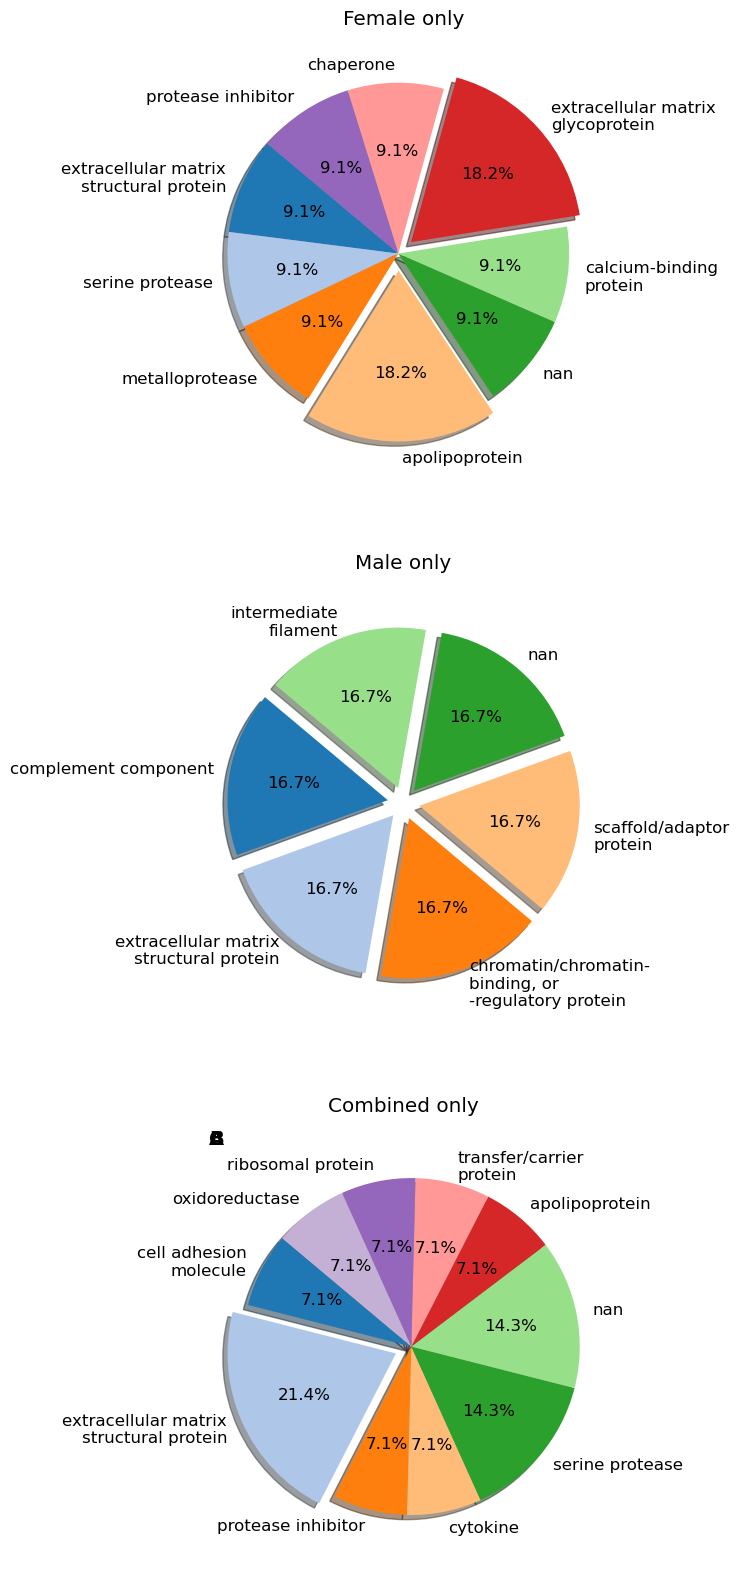

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(5, 20))
# Create pie charts in the subplots
create_pie_chart(panther_f_class, axs[0], 'Female only', plotLabel='A')
create_pie_chart(panther_m_class, axs[1], 'Male only', plotLabel='B')
create_pie_chart(panther_c_class, axs[2], 'Combined only', plotLabel='C')

plt.subplots_adjust(wspace=3)

filename = 'pie_class.svg'
plt.show()
# plt.savefig(filename, format='svg', bbox_inches='tight', pad_inches=0.1)

   Mapped IDs  \
0   CO1A1_RAT   
1    THRB_RAT   
2   MMP13_RAT   
3   APOA2_RAT   
4    PROS_RAT   
5   ANXA5_RAT   
6    PGCA_RAT   
7     NPM_RAT   
8   SERPH_RAT   
9   APOA1_RAT   
10   SPRC_RAT   

                                                                                                                                                                                                                                                                                      PANTHER GO-Slim Biological Process  
0                                                                                                                                                                                                                                                                          extracellular matrix organization(GO:0030198)  
1                      positive regulation of response to stimulus(GO:0048584);regulation of coagulation(GO:0050818);regulation of wound healing(GO:0061041);positive

C:\Users\jtudo\AppData\Local\Temp\ipykernel_2404\3126631741.py:53: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  subplot.legend(sizes, labels=wrapped_labels, loc='right')


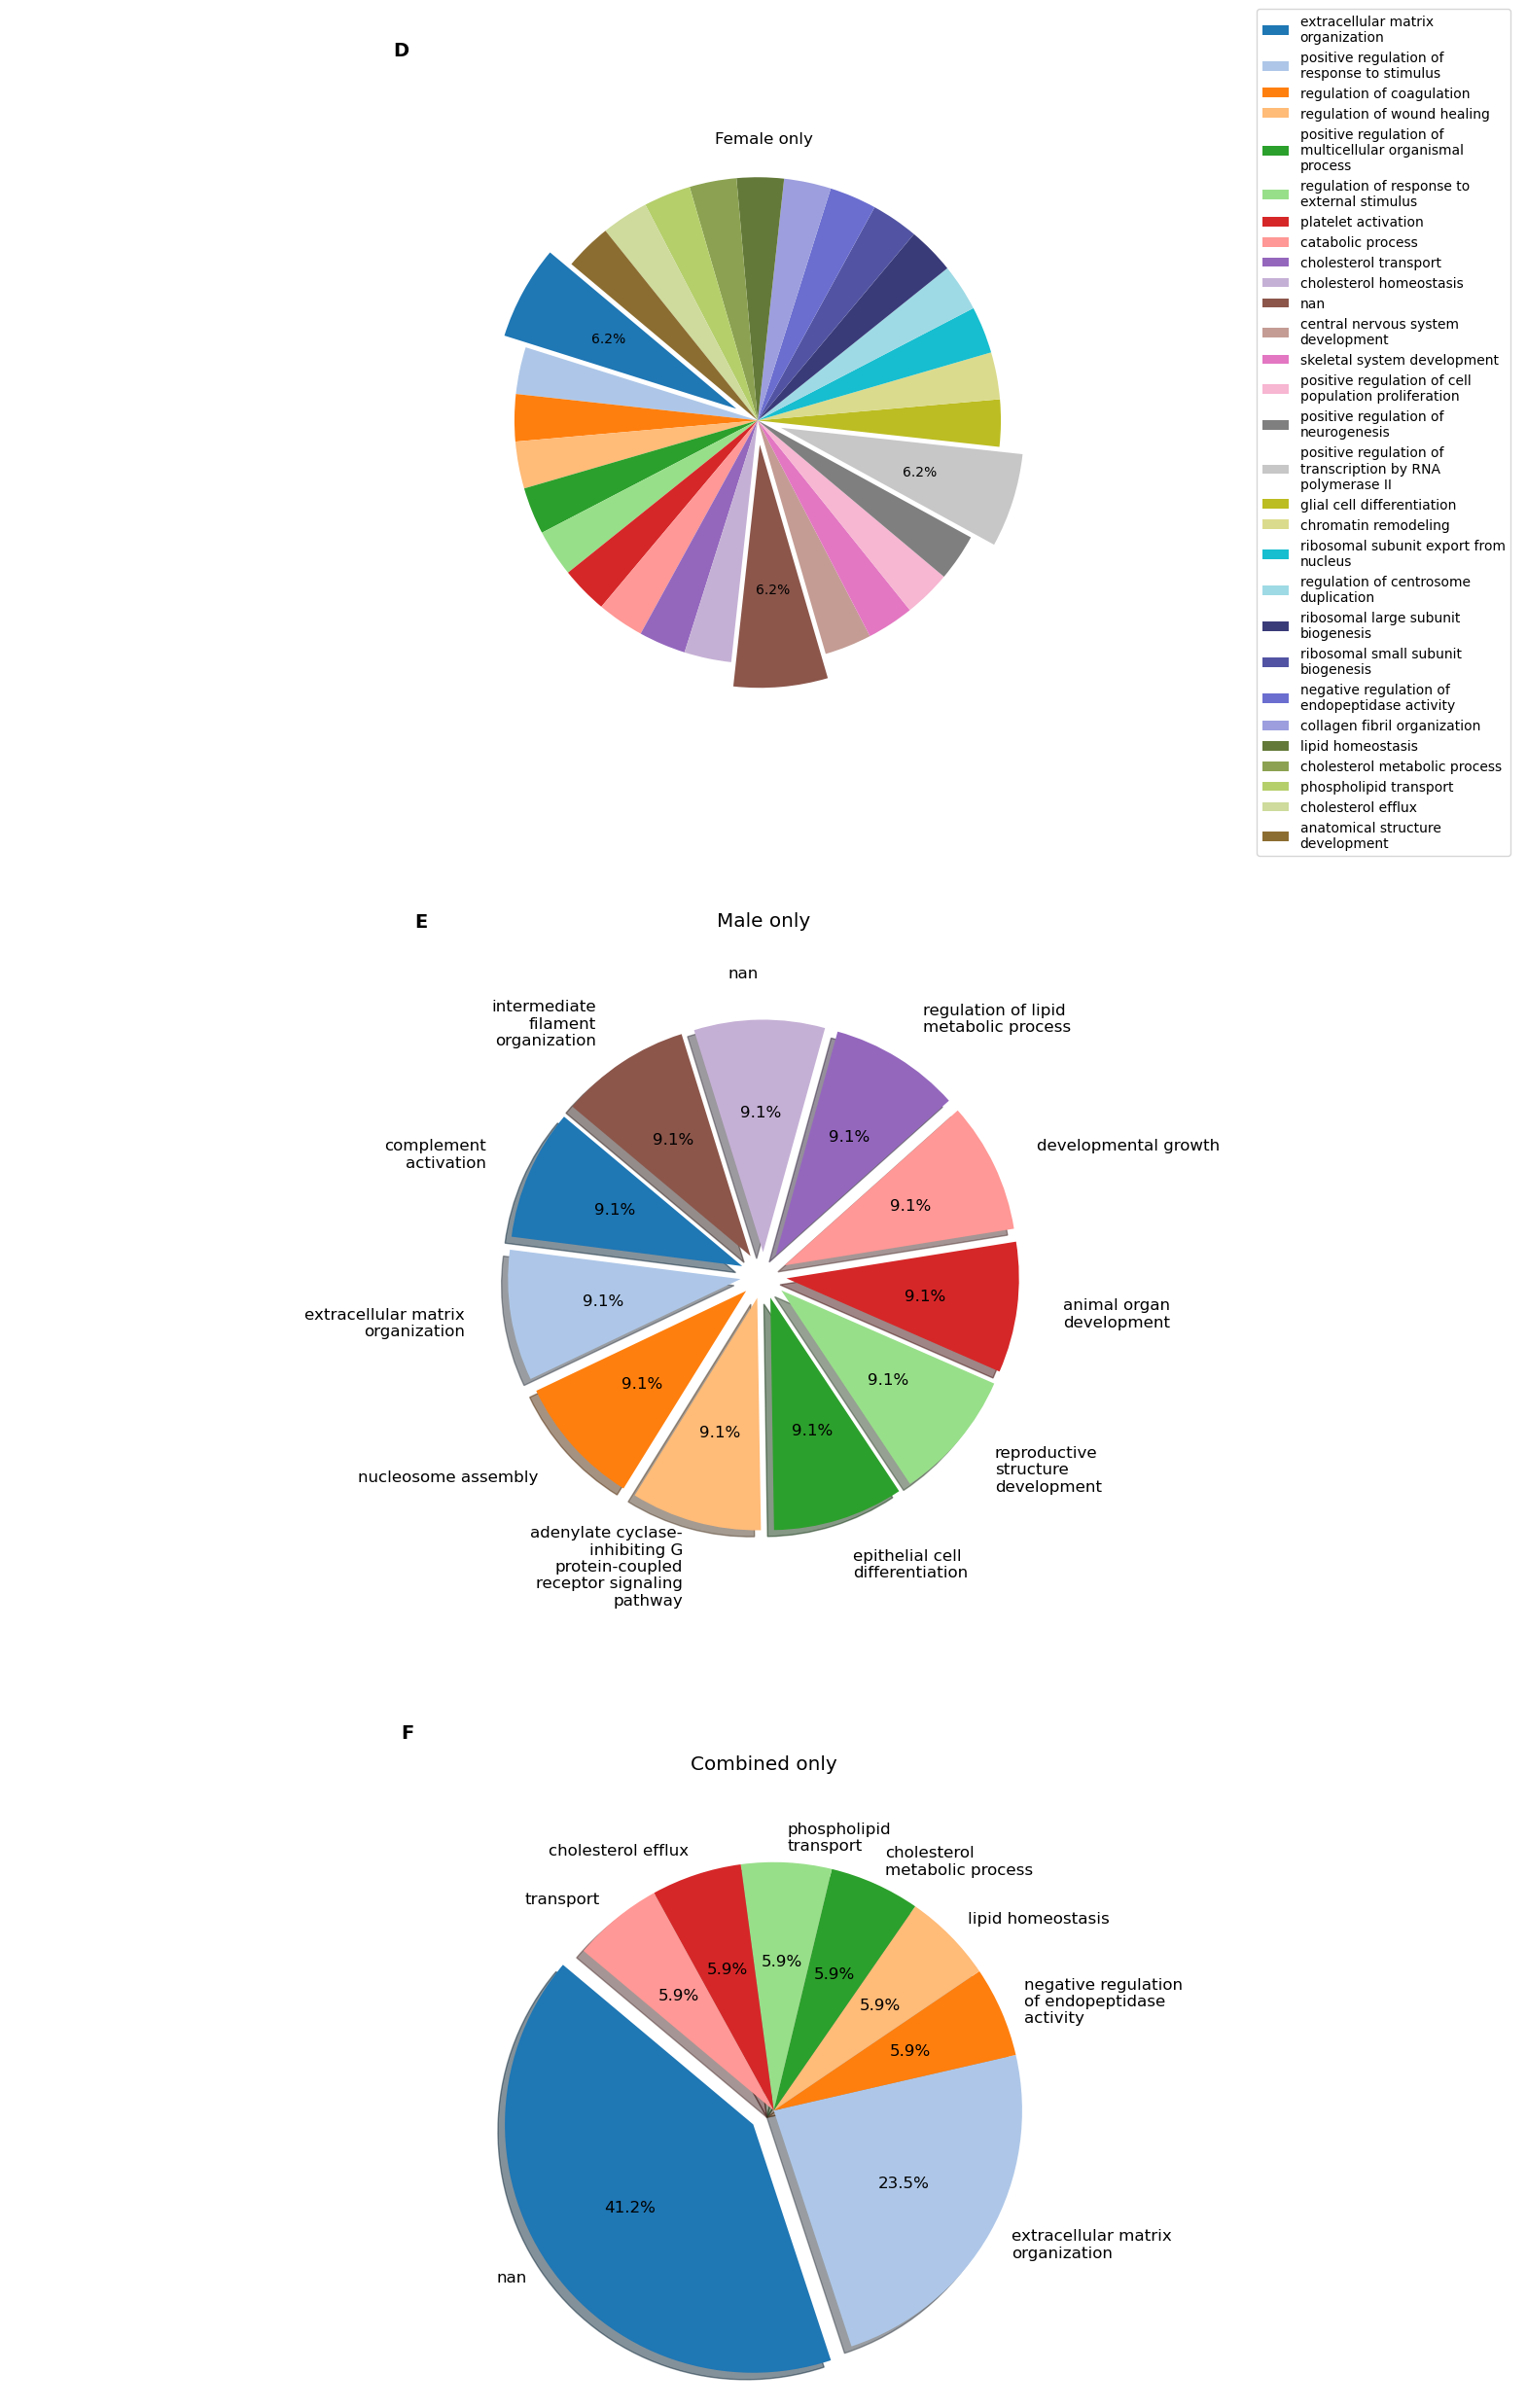

In [25]:
from collections import Counter

def create_pie_chart(data, subplot, title, *args, **kwargs):
    # Extract additional parameters from kwargs
    title_padding = kwargs.get('title_padding', None)
    label_distance = kwargs.get('label_distance', None)
    legend = kwargs.get('legend', None)
    restrictNumShow = kwargs.get('restrictNumShow', None)
    plotLabel = kwargs.get('plotLabel', None)
    
    print(data)
    
    # Prepare data for pie chart
    overall_list = []
    for i in data.iloc[:, 1]:
        i = str(i)
        overall_list.extend(i.split(';'))
    
    counter = Counter(overall_list)
    labels = list(counter.keys())
    sizes = list(counter.values())
    custom_colors = generate_combined_colors(len(overall_list))
    colors = custom_colors[:len(labels)]
    explode = [0.1 if i == max(sizes) else 0 for i in sizes]
    
    # Wrap labels using the custom wrapping function
    wrapped_labels = [custom_wrap(label, 20) for label in labels]
    
    # Plot pie chart on the given subplot
    if legend:
        wrapped_labels = [custom_wrap(label, 30) for label in labels]
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow),
                            startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow),
                            startangle=140)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else:
            subplot.set_title(title)
        subplot.legend(sizes, labels=wrapped_labels, loc='right')
    else:
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow),
                            startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow),
                            startangle=140)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', shadow=True, startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else:
            subplot.set_title(title)
    
    # Add the plot label text to the subplot
    if plotLabel:
        subplot.text(-1.5, 1.5, plotLabel, fontsize=14, fontweight='bold')

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(20, 30))

# Example usage of create_pie_chart
plt.rcParams['font.size'] = 10
create_pie_chart(panther_f_bp, axs[0], 'Female only', legend='legend', restrictNumShow=4, plotLabel='D')

plt.rcParams['font.size'] = 12
create_pie_chart(panther_m_bp, axs[1], 'Male only', title_padding=50, label_distance=1.2, plotLabel='E')

create_pie_chart(panther_c_bp, axs[2], 'Combined only', title_padding=50, plotLabel='F')

# Adjust spacing between the subplots
plt.subplots_adjust(wspace=0.3, hspace=0.5)

# Save the figure
plt.savefig('pie_biological_role.svg', format='svg')

# Optionally show the plot
# plt.show()


AttributeError: 'Axes' object has no attribute 'subplot'

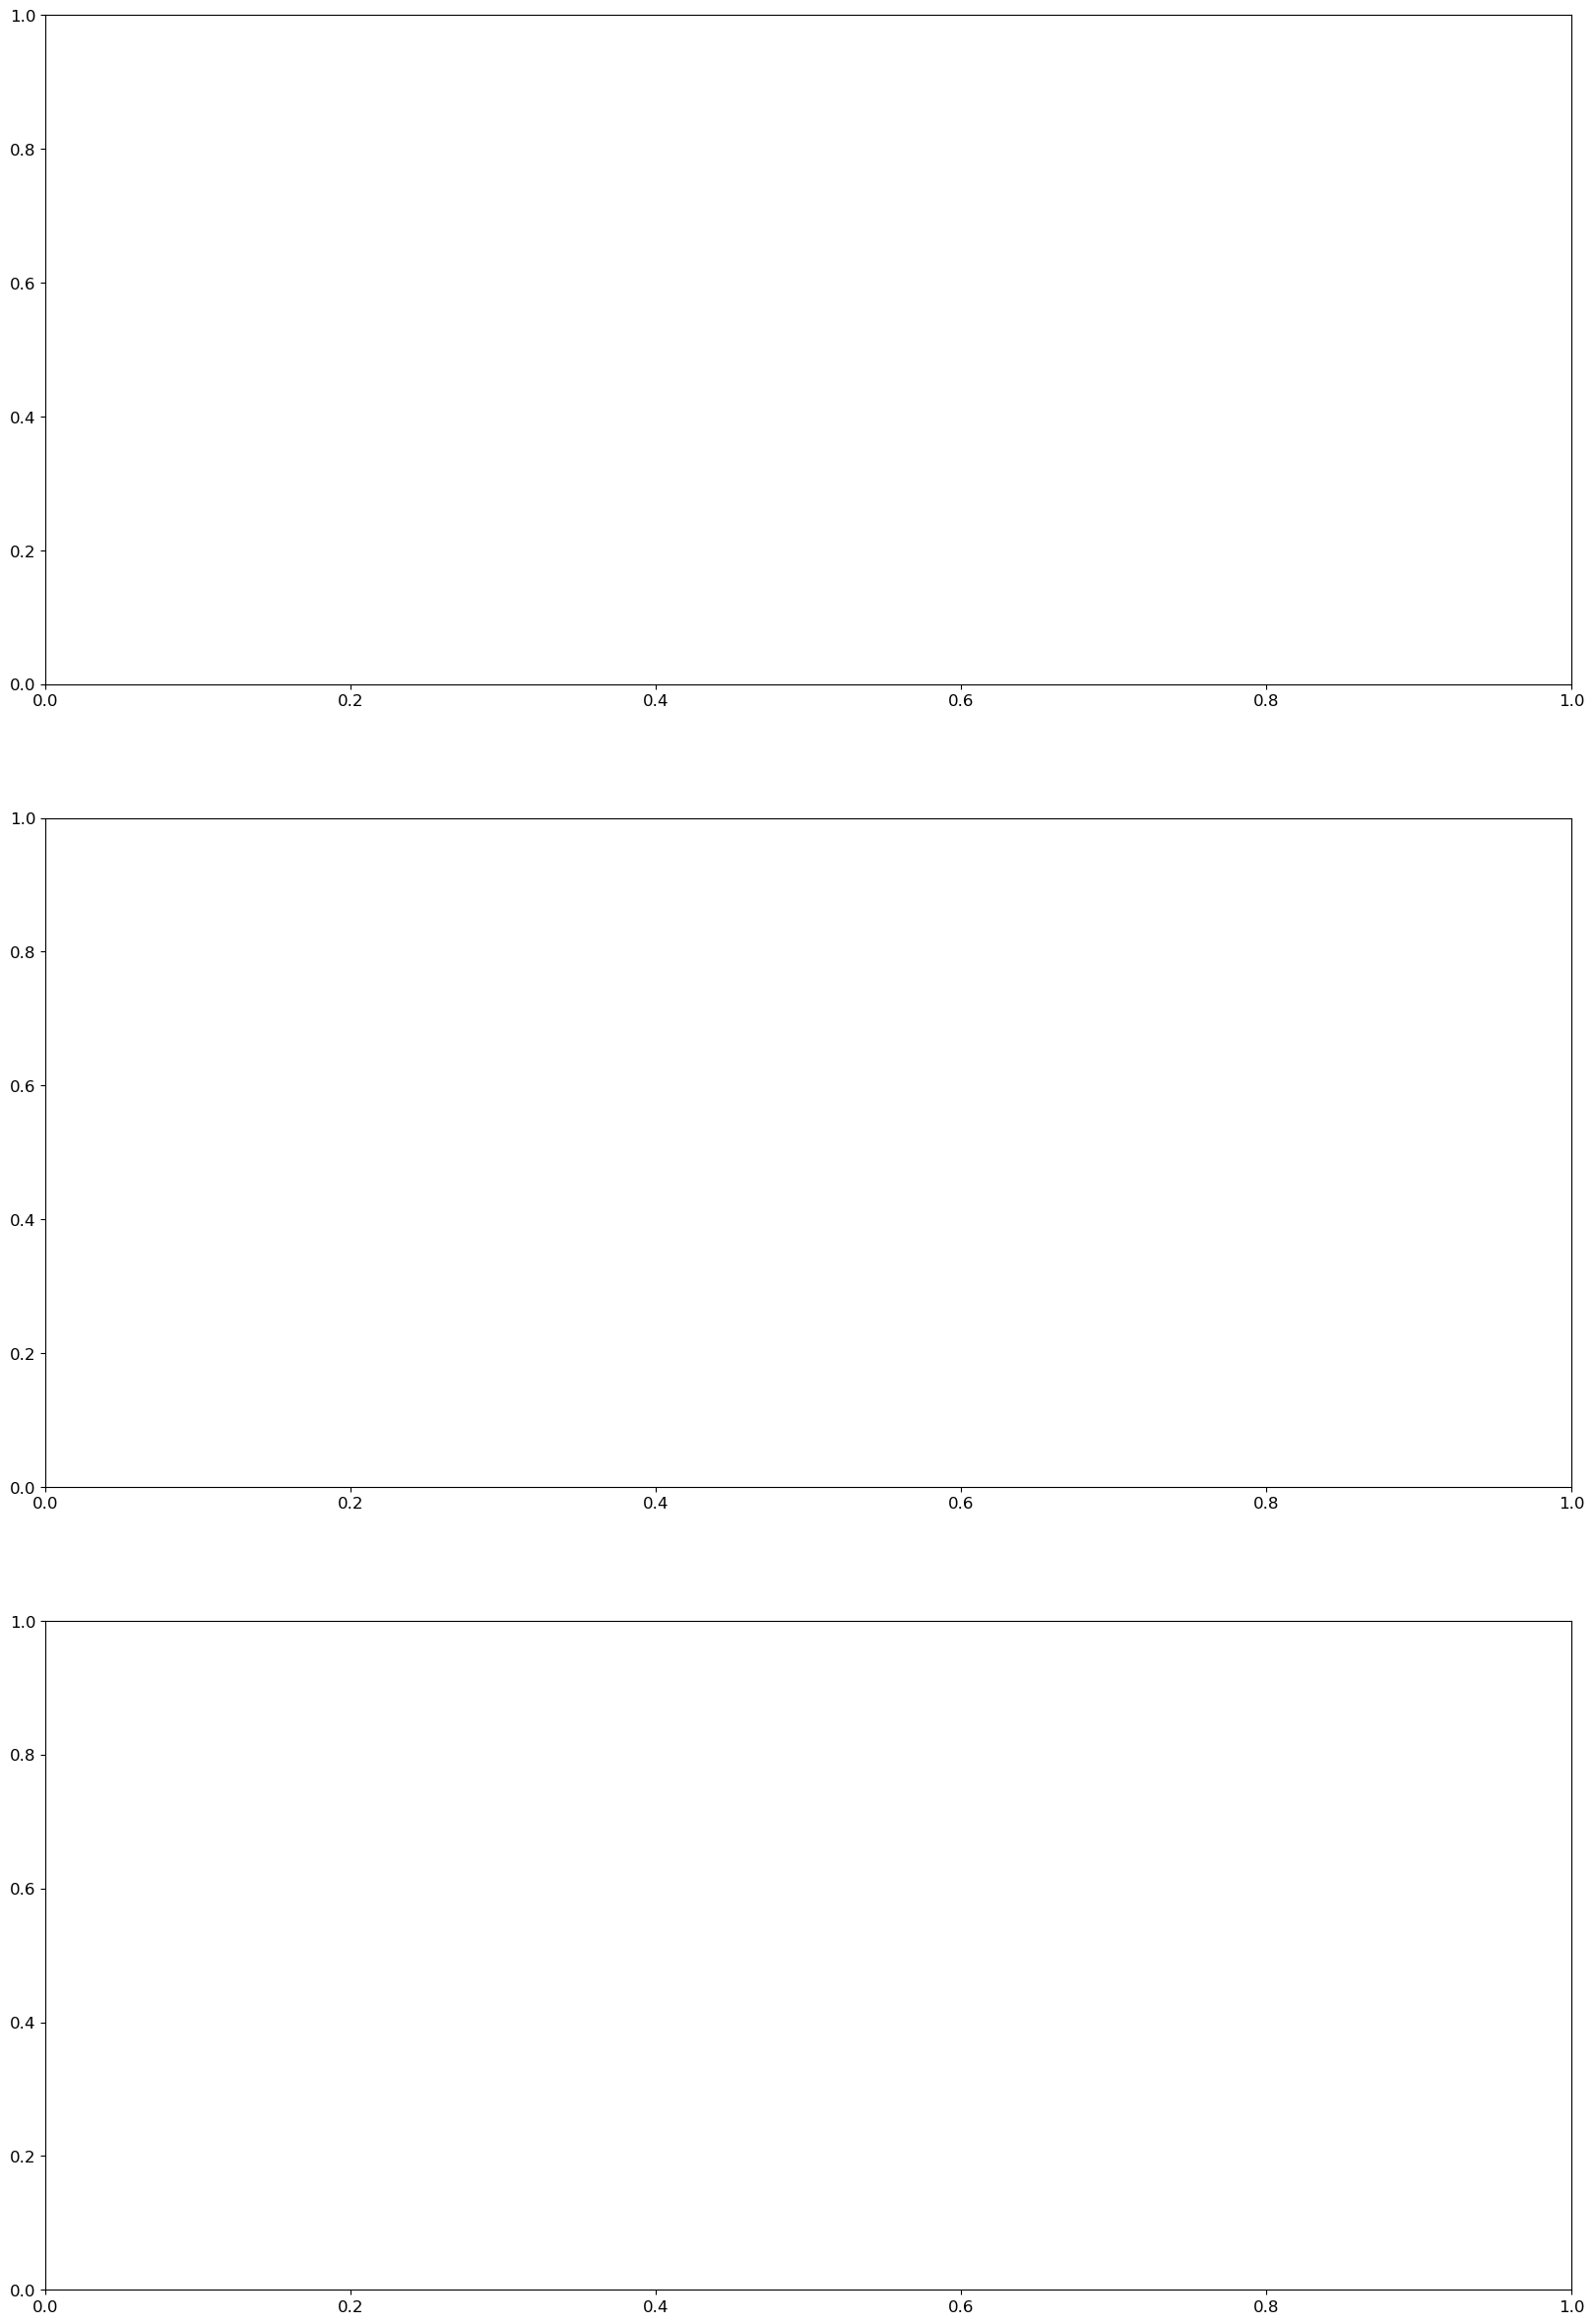

In [26]:
fig, axs = plt.subplots(3, 1, figsize=(20, 30))
# Create pie charts in the subplots
plt.rcParams['font.size'] = 10
axs1 = axs[0]
axs1.subplot(create_pie_chart(panther_f_bp, axs[0], 'Female only', legend='legend', restrictNumShow=4, plotLabel='D'))

plt.rcParams['font.size'] = 12
axs2 = axs[1]
axs2.subplot(create_pie_chart(panther_m_bp, axs[1], 'Male only', title_padding=50, label_distance=1.2, plotLabel='F'))
axs3 = axs[2]
axs3.subplot(create_pie_chart(panther_c_bp, axs[2], 'Combined only', title_padding=50, plotLabel='E'))
plt.subplots_adjust(wspace=10, hspace=0.5)
plt.savefig('pie_biological_role.svg', format='svg')

   Mapped IDs  \
0   CO1A1_RAT   
1    THRB_RAT   
2   MMP13_RAT   
3   APOA2_RAT   
4    PROS_RAT   
5   ANXA5_RAT   
6    PGCA_RAT   
7     NPM_RAT   
8   SERPH_RAT   
9   APOA1_RAT   
10   SPRC_RAT   

                                                                                                                                                                                                                                                                                      PANTHER GO-Slim Biological Process  
0                                                                                                                                                                                                                                                                          extracellular matrix organization(GO:0030198)  
1                      positive regulation of response to stimulus(GO:0048584);regulation of coagulation(GO:0050818);regulation of wound healing(GO:0061041);positive

C:\Users\jtudo\AppData\Local\Temp\ipykernel_2404\3126631741.py:53: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  subplot.legend(sizes, labels=wrapped_labels, loc='right')


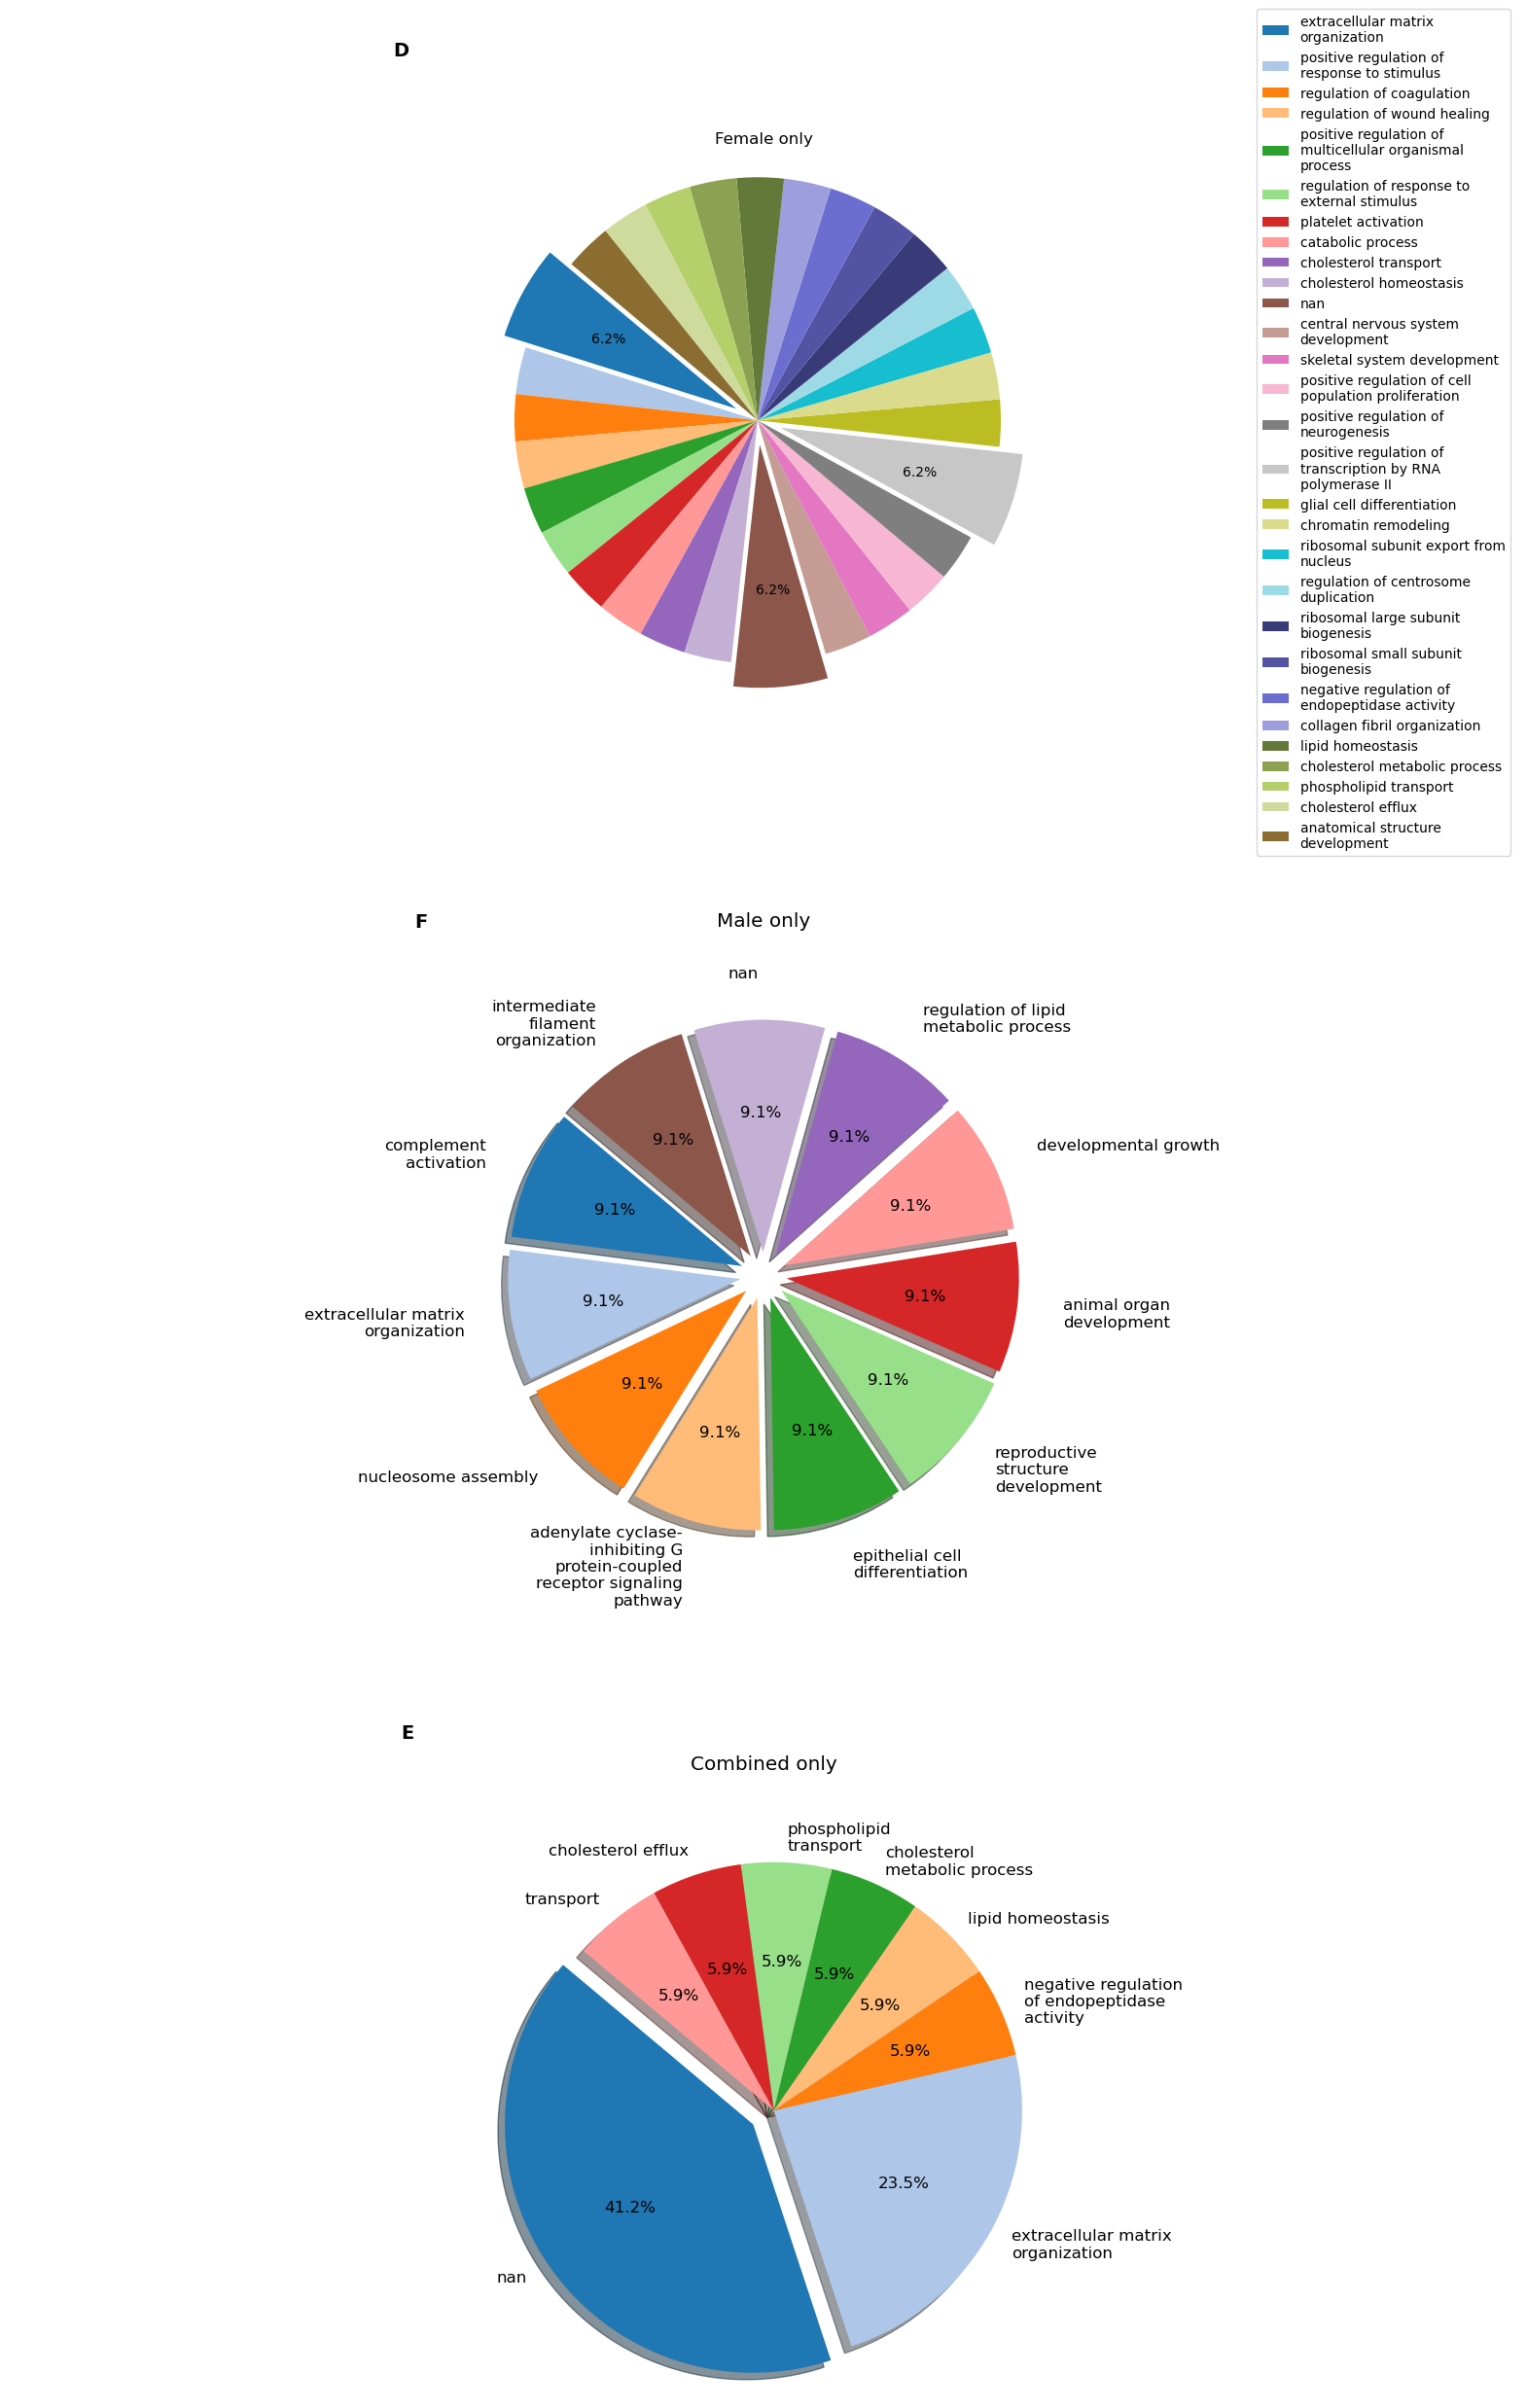

In [27]:
# Assuming 'create_pie_chart' is a function that plots a pie chart on a given axis.
# You'll pass the axis (`ax`) to the function, along with other parameters.

# Create a figure with 3 subplots (3 rows, 1 column)
fig, axs = plt.subplots(3, 1, figsize=(20, 30))

# Set global font size for the plot
plt.rcParams['font.size'] = 10

# Plot pie chart in the first subplot (axs[0])
create_pie_chart(panther_f_bp, axs[0], 'Female only', legend='legend', restrictNumShow=4, plotLabel='D')

# Increase font size for the next chart
plt.rcParams['font.size'] = 12

# Plot pie chart in the second subplot (axs[1])
create_pie_chart(panther_m_bp, axs[1], 'Male only', title_padding=50, label_distance=1.2, plotLabel='F')

# Plot pie chart in the third subplot (axs[2])
create_pie_chart(panther_c_bp, axs[2], 'Combined only', title_padding=50, plotLabel='E')

# Adjust spacing between the subplots
plt.subplots_adjust(wspace=0.3, hspace=0.5)

# Save the figure as an SVG file
plt.savefig('pie_biological_role.svg', format='svg')

# Optionally show the plot
# plt.show()


In [ ]:
data_f.head()

In [28]:
# Prepares dataset for Anova
# Get the data and manipulate into correct format - #_Sample_label #_Male/Female #_Spectra count
data_f_common = data_f[data_f['Uniprot_ID'].isin(commonUnfiltered)]
data_m_common = data_m[data_m['Uniprot_ID'].isin(commonUnfiltered)]

# Fuzzy
# Female
FZ_F = data_f_common[['Uniprot_ID', 'Domain_Name', 'FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)']]
FZ_F['ID'] = data_f_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
FZ_F = FZ_F[['ID', 'FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)']]
FZ_F = pd.melt(FZ_F, id_vars=['ID'], value_vars=['FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
FZ_F['Sex'] = 'F'
FZ_F

# Male
FZ_M = data_m_common[['Uniprot_ID', 'Domain_Name', 'FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)']]
FZ_M['ID'] = data_m_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
FZ_M = FZ_M[['ID', 'FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)']]
FZ_M = pd.melt(FZ_M, id_vars=['ID'], value_vars=['FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
FZ_M['Sex'] = 'M'
FZ_M
Fuzzy = pd.concat([FZ_F, FZ_M], axis=0, ignore_index=True)
Fuzzy = Fuzzy.sort_values(by='ID').reset_index(drop=True)

# Jumbo
# Female
JA_F = data_f_common[['Uniprot_ID', 'Domain_Name', 'JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
JA_F['ID'] = data_f_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
JA_F = JA_F[['ID', 'JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
JA_F = pd.melt(JA_F, id_vars=['ID'], value_vars=['JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
JA_F['Sex'] = 'F'
JA_F

# Male
JA_M = data_m_common[['Uniprot_ID', 'Domain_Name', 'JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]
JA_M['ID'] = data_m_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
JA_M = JA_M[['ID', 'JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]
JA_M = pd.melt(JA_M, id_vars=['ID'], value_vars=['JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
JA_M['Sex'] = 'M'
JA_M
Jumbo = pd.concat([JA_F, JA_M], axis=0, ignore_index=True)
Jumbo = Jumbo.sort_values(by='ID').reset_index(drop=True)
Jumbo

Fuzzy.to_csv('Fuzzy_BS_Comp.csv', sep=',', index=False, header=True)
Jumbo.to_csv('Jumbo_BS_Comp.csv', sep=',', index=False, header=True)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_2404\1988913835.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FZ_F['ID'] = data_f_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
C:\Users\jtudo\AppData\Local\Temp\ipykernel_2404\1988913835.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FZ_M['ID'] = data_m_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
C:\Users\jtudo\AppData\Local\Temp\ipykernel_2404\1988913835.py:28: SettingWithCopyWarning: 

In [ ]:
# Prepares dataset for Anova
# Get the data and manipulate into correct format - #_Sample_label #_Male/Female #_Spectra count
data_f_common = data_f[data_f['Uniprot_ID'].isin(commonFiltered)]
data_m_common = data_m[data_m['Uniprot_ID'].isin(commonFiltered)]

# Fuzzy
# Female
FZ_F = data_f_common[['Uniprot_ID', 'Domain_Name', 'FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)']]
FZ_F['ID'] = data_f_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
FZ_F = FZ_F[['ID', 'FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)']]
FZ_F = pd.melt(FZ_F, id_vars=['ID'], value_vars=['FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
FZ_F['Sex'] = 'F'
FZ_F

# Male
FZ_M = data_m_common[['Uniprot_ID', 'Domain_Name', 'FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)']]
FZ_M['ID'] = data_m_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
FZ_M = FZ_M[['ID', 'FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)']]
FZ_M = pd.melt(FZ_M, id_vars=['ID'], value_vars=['FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
FZ_M['Sex'] = 'M'
FZ_M
Fuzzy = pd.concat([FZ_F, FZ_M], axis=0, ignore_index=True)
Fuzzy = Fuzzy.sort_values(by='ID').reset_index(drop=True)

# Jumbo
# Female
JA_F = data_f_common[['Uniprot_ID', 'Domain_Name', 'JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
JA_F['ID'] = data_f_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
JA_F = JA_F[['ID', 'JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
JA_F = pd.melt(JA_F, id_vars=['ID'], value_vars=['JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
JA_F['Sex'] = 'F'
JA_F

# Male
JA_M = data_m_common[['Uniprot_ID', 'Domain_Name', 'JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]
JA_M['ID'] = data_m_common.apply(lambda row: f"{row['Uniprot_ID']} {row['Domain_Name']}", axis=1)
JA_M = JA_M[['ID', 'JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]
JA_M = pd.melt(JA_M, id_vars=['ID'], value_vars=['JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)'], var_name='Rat_specimen', value_name='peptide_spectral_count')
JA_M['Sex'] = 'M'
JA_M
Jumbo = pd.concat([JA_F, JA_M], axis=0, ignore_index=True)
Jumbo = Jumbo.sort_values(by='ID').reset_index(drop=True)
Jumbo

Fuzzy.to_csv('Fuzzy_BS_Comp_Filtered.csv', sep=',', index=False, header=True)
Jumbo.to_csv('Jumbo_BS_CompFiltered.csv', sep=',', index=False, header=True)

In [ ]:
# FINAL FIGURES

{'APOA1_RAT', 'OSTP_RAT', 'APOA2_RAT', 'RLA2_RAT', 'CO2A1_RAT', 'NPM_RAT', 'SPRC_RAT', 'CO5A1_RAT', 'FETUA_RAT', 'ALBU_RAT', 'MMP13_RAT', 'LUM_RAT', 'THRB_RAT', 'DMP1_RAT', 'PROS_RAT', 'SERPH_RAT', 'CO1A1_RAT', 'FA10_RAT', 'MFGM_RAT', 'PGCA_RAT', 'ANXA5_RAT', 'FA9_RAT', 'COMP_RAT', 'APOE_RAT', 'CO1A2_RAT'} {'OSTP_RAT', 'RLA2_RAT', 'CO2A1_RAT', 'VIME_RAT', 'PRELP_RAT', 'CO5A1_RAT', 'FETUA_RAT', 'CO9_RAT', 'ALBU_RAT', 'LUM_RAT', 'DMP1_RAT', 'H4_RAT', 'COBA1_RAT', 'FA10_RAT', 'MFGM_RAT', 'SAP_RAT', 'COMP_RAT', 'FA9_RAT', 'APOE_RAT', 'CO1A2_RAT'}


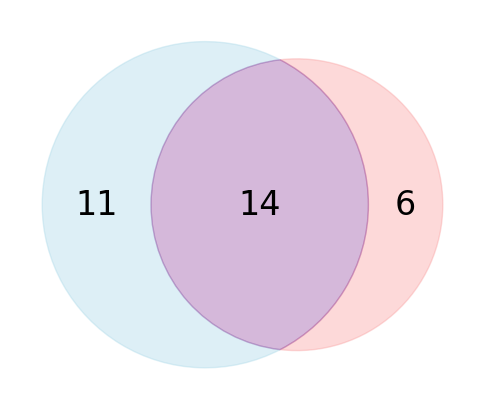

In [71]:
# Plot the venn of proteins with significat age associated differences in male and female datasets
# This will show you what the structure should look like at the end
proteins = findCommon([female_un_sig_proteins, male_un_sig_proteins])

# Plot venn
plt.figure(figsize=(6,6))
# plt.title('Protein biomarkers of ageing identified by relative abundance or PLF', pad=20)

set1 = set(female_un_sig_proteins)
set2 = set(male_un_sig_proteins)

# Create the Venn diagram
venn = venn2([set1, set2], ('', ''))

# Customize colors
venn.get_patch_by_id('10').set_color('#abd9e9')  # Light blue for set 1
venn.get_patch_by_id('01').set_color('#faa0a0')  # Light red for set 2
venn.get_patch_by_id('11').set_color('#984ea3')  # Light purple for intersection

for text in venn.subset_labels:  # Subset labels (numbers inside circles)
    if text:
        text.set_fontsize(24)  # Change to desired font size
plt.savefig("venn_sig_prots.svg", format="svg", bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.close()

In [19]:
# Defining protein class
panther_m = pd.read_csv('../data/pantherGeneList_m_only.txt', sep='\t', header=None)
panther_f = pd.read_csv('../data/pantherGeneList_f_only.txt', sep='\t', header=None)
panther_c = pd.read_csv('../data/pantherGeneList_both.txt', sep='\t', header=None)

column_names = [    
    'Gene ID',
    'Mapped IDs',
    'Gene Name, Gene Symbol, Persistent id, Orthologs',
    'PANTHER Family/Subfamily',
    'PANTHER Protein Class',
    'Species',
    'PANTHER GO-Slim Molecular Function',
    'PANTHER GO-Slim Biological Process',
    'PANTHER GO-Slim Cellular Component',
    'Pathway']

panther_m.columns = column_names 
panther_f.columns = column_names
panther_c.columns = column_names

panther_f_class = panther_f[['Mapped IDs', 'PANTHER Protein Class']]
panther_m_class = panther_m[['Mapped IDs', 'PANTHER Protein Class']]
panther_c_class = panther_c[['Mapped IDs', 'PANTHER Protein Class']]

panther_f_bp = panther_f[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]
panther_m_bp = panther_m[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]
panther_c_bp = panther_c[['Mapped IDs', 'PANTHER GO-Slim Biological Process']]

In [17]:
panther_f_bp

,Mapped IDs,PANTHER GO-Slim Biological Process
0,CO1A1_RAT,extracellular matrix organization(GO:0030198)
1,THRB_RAT,positive regulation of response to stimulus(GO:0048584);regulation of coagulation(GO:0050818);regulation of wound healing(GO:0061041);positive regulation of multicellular organismal process(GO:0051240);regulation of response to external stimulus(GO:0032101);platelet activation(GO:0030168)
2,MMP13_RAT,catabolic process(GO:0009056);extracellular matrix organization(GO:0030198)
3,APOA2_RAT,cholesterol transport(GO:0030301);cholesterol homeostasis(GO:0042632)
4,PROS_RAT,NaN
5,ANXA5_RAT,NaN
6,PGCA_RAT,central nervous system development(GO:0007417);skeletal system development(GO:0001501);positive regulation of cell population proliferation(GO:0008284);positive regulation of neurogenesis(GO:0050769);positive regulation of transcription by RNA polymerase II(GO:0045944);glial cell differentiation(GO:0010001)
7,NPM_RAT,chromatin remodeling(GO:0006338);ribosomal subunit export from nucleus(GO:0000054);regulation of centrosome duplication(GO:0010824);ribosomal large subunit biogenesis(GO:0042273);ribosomal small subunit biogenesis(GO:0042274);positive regulation of transcription by RNA polymerase II(GO:0045944)
8,SERPH_RAT,negative regulation of endopeptidase activity(GO:0010951);collagen fibril organization(GO:0030199)
9,APOA1_RAT,lipid homeostasis(GO:0055088);cholesterol metabolic process(GO:0008203);phospholipid transport(GO:0015914);cholesterol efflux(GO:0033344)


In [18]:
panther_c_class

,Mapped IDs,PANTHER Protein Class
0,COMP_RAT,cell adhesion molecule(PC00069)
1,CO1A2_RAT,extracellular matrix structural protein(PC00103)
2,FETUA_RAT,protease inhibitor(PC00191)
3,OSTP_RAT,cytokine(PC00083)
4,CO2A1_RAT,extracellular matrix structural protein(PC00103)
5,FA10_RAT,serine protease(PC00203)
6,LUM_RAT,NaN
7,DMP1_RAT,NaN
8,APOE_RAT,apolipoprotein(PC00052)
9,ALBU_RAT,transfer/carrier protein(PC00219)


In [189]:
panther_c_bp

,Mapped IDs,PANTHER GO-Slim Biological Process
0,COMP_RAT,NaN
1,CO1A2_RAT,extracellular matrix organization(GO:0030198)
2,FETUA_RAT,negative regulation of endopeptidase activity(GO:0010951)
3,OSTP_RAT,NaN
4,CO2A1_RAT,extracellular matrix organization(GO:0030198)
5,FA10_RAT,NaN
6,LUM_RAT,NaN
7,DMP1_RAT,extracellular matrix organization(GO:0030198)
8,APOE_RAT,lipid homeostasis(GO:0055088);cholesterol metabolic process(GO:0008203);phospholipid transport(GO:0015914);cholesterol efflux(GO:0033344)
9,ALBU_RAT,transport(GO:0006810)


In [18]:
# Function to remove text within brackets
def remove_brackets(text):
    return re.sub(r'\s*\(.*?\)\s*', ' ', text).strip()

def custom_wrap(label, width=20):
    label = str(label)
    label = remove_brackets(label)
    if len(label) > width:
        wrapped_lines = textwrap.wrap(label, width=width, break_long_words=False)
        return '\n'.join(wrapped_lines)
    return label

def generate_combined_colors(n):
    colormaps = [plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c]
    combined_colors = []
    for cm in colormaps:
        cm_colors = [cm(i / cm.N) for i in range(cm.N)]
        combined_colors.extend(cm_colors)

        # Break the loop if we have enough colors
        if len(combined_colors) >= n:
            break
    
    # Return the first n colors from the combined list
    return combined_colors[:n]

def autopct_above_threshold(pct, threshold=5):
    return ('%1.1f%%' % pct) if pct > threshold else ''

def create_pie_chart(data, subplot, title, *args, **kwargs):    
    title_padding = kwargs.get('title_padding', None) 
    label_distance = kwargs.get('label_distance', None)
    legend = kwargs.get('legend', None)
    restrictNumShow = kwargs.get('restrictNumShow', None)
    plotLabel = kwargs.get('plotLabel', None)
    
    # print(data)
    
    overall_list = []
    for i in data.iloc[:,1]:
        i = str(i)
        overall_list.extend(i.split(';'))
    counter = Counter(overall_list)
    labels = list(counter.keys())
    sizes = list(counter.values())
    custom_colors = generate_combined_colors(len(overall_list))
    colors = custom_colors[:len(labels)]
    explode = [0.1 if i == max(sizes) else 0 for i in sizes]
        
    # Wrap labels using the custom wrapping function
    wrapped_labels = [custom_wrap(label, 20) for label in labels]
    
    if legend:
        wrapped_labels = [custom_wrap(label, 30) for label in labels]
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct='%1.1f%%', startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140)
            else:
                subplot.pie(sizes, explode=explode, colors=colors,
                            autopct='%1.1f%%', startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else: 
            subplot.set_title(title)
            subplot.legend(sizes, labels=wrapped_labels, loc='right')       
    else:
        if label_distance:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140, labeldistance=label_distance)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', startangle=140, labeldistance=label_distance)
        else:
            if restrictNumShow:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                        autopct=lambda pct: autopct_above_threshold(pct, restrictNumShow), startangle=140)
            else:
                subplot.pie(sizes, explode=explode, labels=wrapped_labels, colors=colors,
                            autopct='%1.1f%%', startangle=140)
        subplot.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        if title_padding:
            subplot.set_title(title, pad=title_padding)
        else: 
            subplot.set_title(title)
    
    if plotLabel:
        plt.text(-1.2, 1.2, plotLabel, fontsize=14, fontweight='bold')
    
    
    filename = f'{title.replace(" ", "_").lower()}.svg'
    # plt.savefig(filename, format='svg', bbox_inches='tight', pad_inches=0.1)

In [42]:
panther_f_class

,Mapped IDs,PANTHER Protein Class
0,CO1A1_RAT,extracellular matrix structural protein(PC00103)
1,THRB_RAT,serine protease(PC00203)
2,MMP13_RAT,metalloprotease(PC00153)
3,APOA2_RAT,apolipoprotein(PC00052)
4,PROS_RAT,NaN
5,ANXA5_RAT,calcium-binding protein(PC00060)
6,PGCA_RAT,extracellular matrix glycoprotein(PC00100)
7,NPM_RAT,chaperone(PC00072)
8,SERPH_RAT,protease inhibitor(PC00191)
9,APOA1_RAT,apolipoprotein(PC00052)


In [43]:
panther_m_class

,Mapped IDs,PANTHER Protein Class
0,CO9_RAT,complement component(PC00078)
1,COBA1_RAT,extracellular matrix structural protein(PC00103)
2,H4_RAT,"chromatin/chromatin-binding, or -regulatory protein(PC00077)"
3,SAP_RAT,scaffold/adaptor protein(PC00226)
4,PRELP_RAT,NaN
5,VIME_RAT,intermediate filament(PC00129)


In [44]:
panther_c_class

,Mapped IDs,PANTHER Protein Class
0,COMP_RAT,cell adhesion molecule
1,CO1A2_RAT,extracellular matrix structural protein
2,FETUA_RAT,protease inhibitor
3,OSTP_RAT,cytokine
4,CO2A1_RAT,extracellular matrix structural protein
5,FA10_RAT,serine protease
6,LUM_RAT,NaN
7,DMP1_RAT,NaN
8,APOE_RAT,apolipoprotein
9,ALBU_RAT,transfer/carrier protein


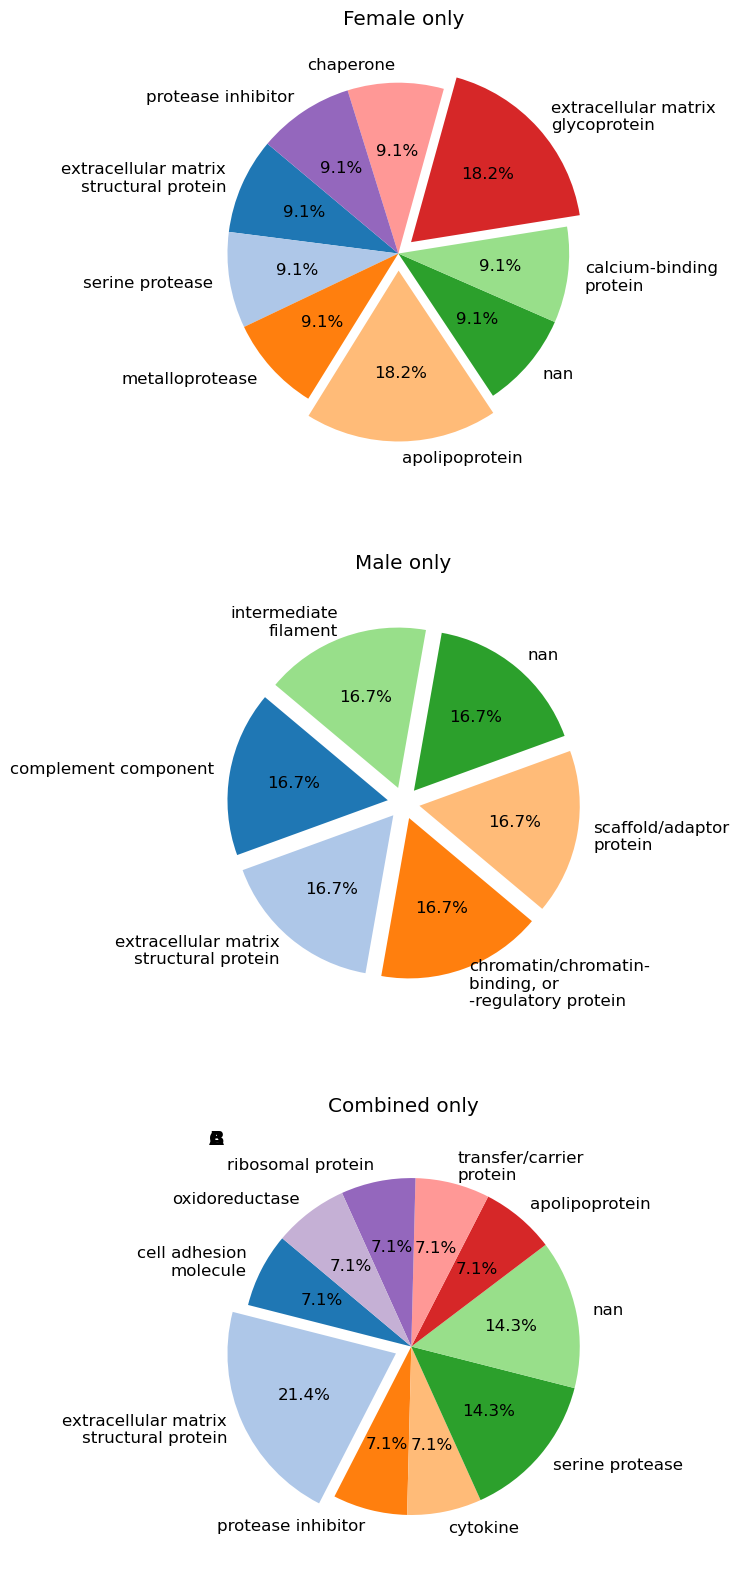

In [41]:
fig, axs = plt.subplots(3, 1, figsize=(5, 20))
# Create pie charts in the subplots
create_pie_chart(panther_f_class, axs[0], 'Female only', plotLabel='A')
create_pie_chart(panther_m_class, axs[1], 'Male only', plotLabel='B')
create_pie_chart(panther_c_class, axs[2], 'Combined only', plotLabel='C')

plt.subplots_adjust(wspace=3)

filename = 'pie_class.svg'
plt.show()
# plt.savefig(filename, format='svg', bbox_inches='tight', pad_inches=0.1)

In [21]:
# panther_c_class_no_brackets

def remove_brackets(text):
    if pd.isna(text):
        return text  # Keep NaN as is
    return re.sub(r'\s*\(.*?\)\s*', ' ', text).strip()

# Apply the updated function
panther_c_class['PANTHER Protein Class'] = panther_c_class['PANTHER Protein Class'].apply(remove_brackets)
panther_c_class['PANTHER Protein Class'].unique().tolist()
sizeslist = []
for i in panther_c_class['PANTHER Protein Class'].unique().tolist():
    fr = panther_c_class['PANTHER Protein Class'].tolist().count(i)
    sizeslist.append(fr)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_21312\2701648789.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panther_c_class['PANTHER Protein Class'] = panther_c_class['PANTHER Protein Class'].apply(remove_brackets)


In [20]:
col_ECM = '#228833'
col_transporter = '#2c7bb6'
col_chaperone = '#faa0a0'
col_enzyme = '#984ea3'
col_calciumbinding = '#98df8a'
col_proteaseinhibitor = '#332288'
col_celladhesion = '#c00000'
col_ribosomal = '#a6761d'
col_signalling = '#f5c518'
col_complement = '#abd9e9'
col_chromatin = '#999999'
col_cytoskeletal = '#f46d43'

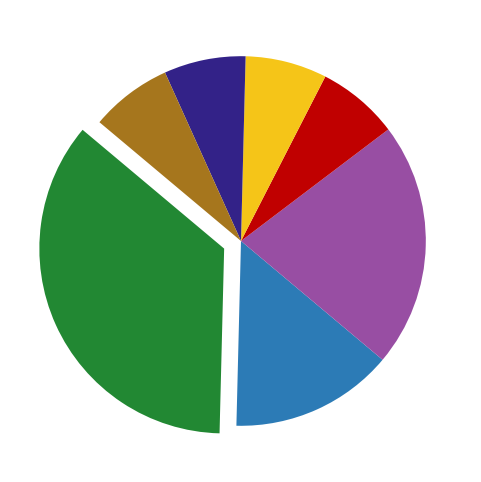

In [22]:
# Data
labels = ['','','','','','','']
sizes = [5, 2, 3, 1, 1, 1, 1]  # Percentages or values
colors = [col_ECM, col_transporter, col_enzyme, col_celladhesion, col_signalling, col_proteaseinhibitor,col_ribosomal]  # Optional colors
explode = (0.1, 0.0, 0.0, 0.0,0.0, 0.0, 0.0)  # Highlight the first slice

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode, 
    # autopct='%1.1f%%', 
    startangle=140
)
# plt.title('Simple Pie Chart')
plt.savefig('shared_classes_pie.svg', format='svg')
plt.show()

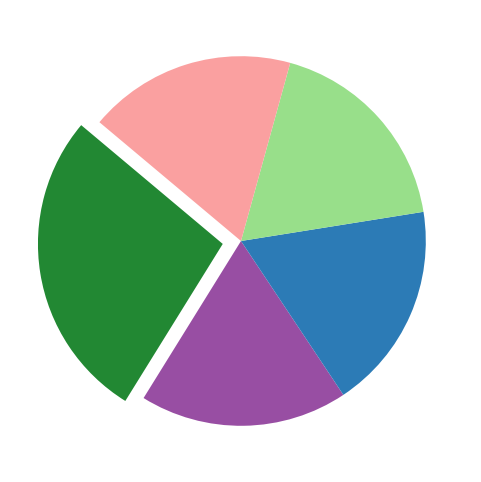

In [26]:
# Data
labels = ['','','','','']
sizes = [3, 2, 2, 2, 2]  # Percentages or values
colors = [col_ECM, col_enzyme, col_transporter, col_calciumbinding, col_chaperone]  # Optional colors
explode = (0.1, 0.0, 0.0, 0.0,0.0)  # Highlight the first slice

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode, 
    # autopct='%1.1f%%', 
    startangle=140
)
# plt.title('Simple Pie Chart')
plt.savefig('female_classes_pie.svg', format='svg')
plt.show()


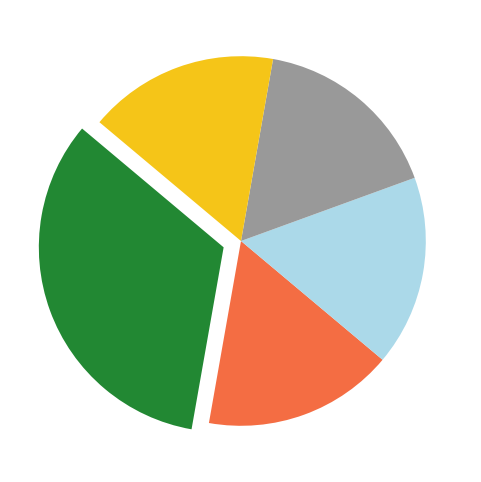

In [83]:
# Data
labels = ['','','','','']
sizes = [2, 1, 1, 1, 1,]  # Percentages or values
colors = [col_ECM, col_cytoskeletal, col_complement, col_chromatin, col_signalling]  # Optional colors
explode = (0.1, 0.0, 0.0, 0.0, 0.0)  # Highlight the first slice

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode, 
    # autopct='%1.1f%%', 
    startangle=140
)
# plt.title('Simple Pie Chart')
plt.savefig('male_classes_pie.svg', format='svg')
plt.show()
